# Similarity-Threshold Geometric SCM Prior — Topology from a Similarity Kernel

This notebook is a variant of the *geometric SCM prior*, in which the graph topology is produced **inside** the structural causal model (SCM) rather than by a separate graph prior. As before, we sample a few extra **geometric neurons** from the same MLP-DAG that already generates the features $X$ and label $y$; their per-node values form a low-dimensional embedding $\Phi \in \mathbb{R}^{n \times n_\text{geo}}$.

The distance-threshold variant connects two nodes whenever their embeddings are *close*, $D(\tilde\Phi_u,\tilde\Phi_v)\le\varepsilon$ — a random geometric graph (RGG). **Here we change the connectivity rule from a distance to a similarity.** Given a similarity measure $\mathrm{sim}(\cdot,\cdot)$ we connect two nodes whenever they are *similar enough*:

$$ E \;=\; \big\{\, (u,v) : u \neq v,\ \mathrm{sim}(\Phi^{\mathrm f}_u, \Phi^{\mathrm f}_v) > \tau \,\big\}, \qquad \tau = 0.5\ \text{(default)}. $$

We demonstrate three similarity measures of increasing expressivity:

1. **Cosine** — $\mathrm{sim}(a,b)=\langle a,b\rangle/(\lVert a\rVert\,\lVert b\rVert)$.
2. **Normalised bilinear** — $\mathrm{sim}(a,b)=\langle La,Lb\rangle/(\lVert La\rVert\,\lVert Lb\rVert)$ with $L\sim\mathcal N(0,1)$ — cosine under a *random linear warp*.
3. **Random-MLP feature cosine** — $\mathrm{sim}(a,b)=\langle\varphi(a),\varphi(b)\rangle/(\lVert\varphi(a)\rVert\,\lVert\varphi(b)\rVert)$ with $\varphi$ a random MLP independent of the SCM — cosine in a *random nonlinear feature space*.

Cosine reads angles **from the origin**, so the most important modelling choice is where the origin sits relative to the embedding. We use **no per-coordinate normalisation** (the cloud keeps its native SCM scale) and instead apply a **data-free analytic correction for the bias that one-sided activations inject** — derived in §1.5 and validated in §3g.

In [1]:
import math
from dataclasses import dataclass, field
from typing import Callable

import numpy as np
import torch
import matplotlib.pyplot as plt
import networkx as nx

torch.manual_seed(0)
np.random.seed(0)

# --- Toy hyperparameters (small so DAGs and graphs stay easy to plot) ---
N_FEATURES     = 10   # number of observed feature columns
N_CLASSES      = 3    # number of discrete classes for the supervised task
SCM_LAYERS     = 4    # depth of the SCM's MLP-DAG
SCM_HIDDEN     = 16   # width of each layer in the SCM
N_NODES_GRAPH  = 64   # nodes in a graph dataset

# --- Number of geometric neurons used to embed nodes for the topology ---
N_GEO          = 3    # |N_g| — chosen so the cosine degree calibration below applies
SIM_THRESHOLD  = 0.5  # tau — connect nodes whose similarity exceeds this

## 1. The similarity-threshold geometric SCM prior — math

### 1.1 The base SCM recipe

The PFN-style SCM prior generates one synthetic dataset in six steps:

1. **Sample architecture.** $L,H$ from a TNLU distribution.
2. **Build an MLP-DAG.** Dense $L$-layer MLP with $H$ neurons per layer; weights $W_{ij}\sim\mathrm{TNLU}(10,0.01)$; each edge dropped with probability $\rho=0.9\cdot\mathrm{Beta}(a,b)$.
3. **Pick a single activation** $a\sim\mathrm{Uniform}\{\mathrm{Tanh},\mathrm{LeakyReLU},\mathrm{ELU},\mathrm{Identity}\}$.
4. **Pick observed nodes.** $k$ feature neurons $N_x$ and one label neuron $N_y$.
5. **Propagate noise.** $z_i = a\big(\sum_{j\in\mathrm{pa}(i)}W_{ij}z_j + \varepsilon_i\big)$. Read off $X$ at $N_x$ and $\hat y$ at $N_y$.
6. **Discretise the target.** Sample $N_c-1$ boundaries from the sorted $\hat y$; bucket into class IDs and shuffle.

Steps 1–3, 5, 6 are unchanged. As in the distance variant we modify Step 4 (read off extra geometric neurons) and replace Step 7 (the topology rule).

### 1.2 Geometric neurons (the embedding $\Phi$)

Let $Z = \{(\ell,i):\ \ell\in\{1,\dots,L\},\ i\in\{1,\dots,H\}\}$ be the latent set of all $L\cdot H$ post-activation neurons. The label node lives in the last layer, $N_y \subset \{(L, i)\}$. The feature neurons $N_x$ are drawn uniformly over the latent set excluding the label. We **additionally** draw $n_\text{geo}$ geometric neurons

$$ N_g \;\sim\; \mathrm{Uniform}\Big(\binom{Z\,\setminus\,(N_x\cup N_y)}{\,n_\text{geo}\,}\Big), $$

disjoint from $N_x$ and $N_y$. The forward pass is unchanged; we read off three things per node $u$:

- $X_u \in \mathbb{R}^{k}$ — values at $N_x$,
- $\hat y_u \in \mathbb{R}$ — value at $N_y$,
- $\Phi_u \in \mathbb{R}^{n_\text{geo}}$ — values at $N_g$ (the embedding).

$X$ and $\hat y$ go through Step 6 exactly as before; $\Phi$ feeds the new topology rule. **This is byte-for-byte the geometric notebook's SCM** — the similarity prior changes only Step 7.

### 1.3 Step 7 (replaced): similarity-threshold connectivity

The distance variants connect *close* points, $D(\tilde\Phi_u,\tilde\Phi_v)\le\varepsilon$. Here we replace the distance $D$ by a **similarity** $\mathrm{sim}$ and flip the test to connect *similar* points:

$$ E = \big\{(u,v): u\neq v,\ \mathrm{sim}(\Phi^{\mathrm f}_u, \Phi^{\mathrm f}_v) > \tau \big\}, \qquad \tau = 0.5\ \text{(default)}, $$

where $\Phi^{\mathrm f}$ is $\Phi$ placed in a chosen **frame** (the origin/normalisation choice of §1.5). All three similarities below are **symmetric** and equal $1$ on the diagonal, so the graph is undirected and self-loops are dropped.

### 1.4 Three similarity measures

**(1) Cosine.** $\mathrm{sim}(a,b) = \langle a,b\rangle/(\lVert a\rVert\,\lVert b\rVert)$. Pure angular similarity in the SCM's geometric coordinates.

**(2) Normalised bilinear (random metric).** With $L$ sampled entrywise from a standard Gaussian,

$$ \mathrm{sim}(a,b) = \frac{(La)^\top(Lb)}{\lVert La\rVert\,\lVert Lb\rVert} = \frac{a^\top M b}{\sqrt{a^\top M a}\,\sqrt{b^\top M b}}, \qquad M = L^\top L \succeq 0. $$

This is the **generalised cosine under the inner product $\langle a,b\rangle_M = a^\top M b$** — i.e. cosine after a random *linear* warp of the space. $M=I$ (e.g. $L$ orthogonal) recovers plain cosine; a random $L$ rotates and stretches the geometry so that a random set of directions becomes 'aligned'. With $L$ of shape $(m,d)$: $m\ge d$ warps invertibly, $m<d$ first projects onto a random $m$-dimensional subspace. It injects a layer of topology randomness *independent* of the SCM draw.

**(3) Random-MLP feature cosine (random kernel).** Let $\varphi$ be a small MLP with random weights, **independent of the SCM**. Then

$$ \mathrm{sim}(a,b) = \frac{\varphi(a)^\top\varphi(b)}{\lVert\varphi(a)\rVert\,\lVert\varphi(b)\rVert}, $$

cosine in a random *nonlinear* feature space — a random kernel $k(a,b)$. The nonlinearity lets 'similar' regions curve, bending neighbourhoods around the manifold the SCM produced; this is the most expressive of the three. ($\varphi$ uses a **symmetric (odd) hidden activation** — `tanh`, `sin`, `erf`, `asinh`, or `identity` — with a linear read-out. Oddness is deliberate: an odd map sends the centred embedding to a centred feature cloud, so the origin sensitivity of §1.5 never recurs *inside* $\varphi$ and no correction is needed there. The linear read-out makes $n_\text{layers}{=}1$ collapse to the bilinear kernel, so the three measures form one continuous ladder.)

The three form a ladder of expressivity: **cosine (fixed) $\to$ bilinear (random linear warp) $\to$ MLP (random nonlinear warp).**

### 1.5 The origin problem, and an analytic activation-bias correction (the default frame)

**Cosine reads angles from the origin.** All three measures normalise by vector norms, so they are invariant to a global rescaling $\Phi\to\lambda\Phi$ but *not* to a translation $\Phi\to\Phi+t$. Where the origin sits relative to the cloud is therefore the decision that matters most — and it is exactly the decision the distance variants' min-max normalisation gets *wrong* for similarity (min-max pushes every point into the positive orthant $[0,1]^d$, forcing all cosines into $[0,1]$ and clustering them near $+1$).

Write each geometric coordinate as

$$ \Phi_{u,d} = c_d + s_{u,d}, \qquad c_d := \mathbb E[\Phi_{\cdot,d}],\quad \mathbb E[s_{\cdot,d}]=0. $$

The offset $c_d$ is **the same for every node** — it carries no information distinguishing node $u$ from node $v$. But cosine sees it: a nonzero $c$ tilts every vector $\Phi_u$ toward the common direction $c$ and inflates every pairwise cosine; when $\lVert c\rVert$ dominates the signal spread $\lVert s\rVert$, all cosines $\to +1$ and the graph becomes complete. Because $c$ is node-independent, **subtracting it removes no node-level signal — it only moves the origin to the cloud's centroid, where angles are meaningful.** That is what lets us correct the bias for free.

**Where $c$ comes from: the activation.** With no normalisation the embedding is the raw post-activation $z=a(\mathrm{pre})$. For a (roughly) zero-mean pre-activation, *odd/linear* activations (tanh, identity) give $\mathbb E[a(\mathrm{pre})]=0$ so $c\approx 0$ — no bias; *one-sided* activations (leaky\_relu, elu) give $\mathbb E[a(\mathrm{pre})]>0$ so $c>0$ and the cloud drifts into a shared orthant. Since we **know** the activation, we can compute $c$ analytically and subtract it — a prior-level correction that never looks at the realised $\Phi$. This is the default frame, `normalize='activation'`.

**The activation moment under a Gaussian.** Model each neuron's pre-activation as Gaussian, $\mathrm{pre}\sim\mathcal N(\mu,\sigma^2)$ (justified by a CLT: $\mathrm{pre}$ is a weighted sum over many parents plus noise). Then

$$ \mathbb E[a(\mathrm{pre})] = \int a(t)\,\mathcal N(t;\mu,\sigma^2)\,dt \;=\; \frac{1}{\sqrt\pi}\sum_{i} w_i\, a\!\big(\mu + \sigma\sqrt2\,\xi_i\big), $$

the last step being **Gauss–Hermite quadrature** (nodes $\xi_i$, weights $w_i$ for the weight $e^{-x^2}$; the substitution $t=\mu+\sigma\sqrt2\,x$ turns the Gaussian integral into the GH form, and $\tfrac{1}{\sqrt\pi}\sum_i w_i = 1$). One formula covers every activation; for the four here it also has closed forms (with $\Phi,\phi$ the standard-normal CDF/PDF):

| $a$ | $\mathbb E[a(\mathcal N(\mu,\sigma^2))]$ | at $\mathcal N(0,1)$ | note |
|---|---|---|---|
| identity | $\mu$ | $0$ | exact |
| tanh | (no elementary form) | $0$ | bounded; saturates |
| relu | $\mu\,\Phi(\mu/\sigma)+\sigma\,\phi(\mu/\sigma)$ | $1/\sqrt{2\pi}\approx0.399$ | $\propto\sigma$ at $\mu=0$ |
| leaky\_relu$(\gamma)$ | relu term $+\,\gamma\big(\mu\,\Phi(-\mu/\sigma)-\sigma\,\phi(\mu/\sigma)\big)$ | $\tfrac{1-\gamma}{\sqrt{2\pi}}\approx0.395$ | $\propto\sigma$ at $\mu=0$ |
| elu | $\mu\Phi(\tfrac{\mu}{\sigma})+\sigma\phi(\tfrac{\mu}{\sigma}) + e^{\mu+\sigma^2/2}\Phi(-\tfrac{\mu}{\sigma}-\sigma) - \Phi(-\tfrac{\mu}{\sigma})$ | $\approx0.161$ | $C^1$ |

Two consequences worth flagging. relu/leaky\_relu are *positively homogeneous*, so their offset **scales with $\sigma$** — a fixed constant will not do, because the SCM's TNLU weights make $\sigma$ vary by orders of magnitude across draws and across layers. tanh *saturates*, so its offset stays bounded in $(-1,1)$. And for tanh/identity the offset is $\approx 0$, so the correction is a **no-op** there and `'activation'` coincides with raw `'none'`.

**Propagating the moments through the DAG.** We do not observe each neuron's $(\mu,\sigma)$; we compute them from the SCM alone. The input layer is $z^0\sim\mathcal N(0,1)$ per coordinate. Treating coordinates within a layer as independent (a mean-field approximation), the pre-activation of layer $\ell$ is an affine map of the previous post-activations plus noise $\varepsilon\sim\mathcal N(0,\sigma_\varepsilon^2)$, with moments

$$ \mu^{\mathrm{pre}}_{\ell} = W_\ell\, m_{\ell-1}, \qquad (\sigma^{\mathrm{pre}}_{\ell})^2 = (W_\ell\!\odot\! W_\ell)\, v_{\ell-1} + \sigma_\varepsilon^2, $$

and the post-activation moments follow from the GH map: $m_\ell=\mathbb E[a(\mathcal N(\mu^{\mathrm{pre}},\sigma^{\mathrm{pre}2}))]$, $v_\ell=\mathrm{Var}[\cdot]$. Recursing from layer $1$ to $L$ gives a mean $m_{\ell,i}$ for every neuron; the offset for geometric neuron $d$ is $c_d = m$ at its $(\ell,i)$. **This uses only the weights and the activation — it never reads $\Phi$.** A corollary of the recursion: the offset *compounds across layers* (a biased layer mean feeds the next pre-activation), so deep geometric neurons can carry large, sign-variable offsets.

The mean-field independence and Gaussian-pre assumptions are approximations. §3g validates them two ways: the predicted $c$ matches the empirical mean of $\Phi$ (to a few percent for the one-sided activations), and subtracting $c$ collapses the raw cosine bias (a near-complete graph becomes a meaningful one) while being a no-op for tanh/identity. The correction is robust — it removes the bulk of the bias even when the moment estimate is a few percent off — and it **preserves per-axis scale** (unlike z-score), leaving the SCM's native angular geometry, the very thing cosine reads, intact.

*Why the kernels don't reintroduce the problem.* Centering $\Phi$ also centres the bilinear features ($\mathbb E[L\Phi]=L\,\mathbb E[\Phi]=\mathbf 0$). For the MLP we restrict $\varphi$ to a **symmetric (odd) activation**: an odd map sends a centred cloud to a (roughly) centred cloud at every layer, so $\varphi(\Phi)$ stays centred and the offset never reappears in $\varphi$'s feature space — by construction, not by patching. The analytic correction of §1.5 is therefore needed in exactly one place: the **raw embedding $\Phi$** that cosine and the bilinear kernel read directly.

### 1.6 Threshold semantics and a degree calibration

The threshold $\tau$ plays the role $\varepsilon$ did in the RGG, but inverted: connect when similarity *exceeds* $\tau$. The default $\tau=0.5$ is interpretable for cosine — it is a fixed angular cone, $\cos\theta>0.5\iff\theta<60^\circ$.

For $n_\text{geo}=3$ there is a clean baseline. If the centred embedding directions were isotropic — uniform on the sphere $S^2$ — then by the **hat-box theorem** (Archimedes) the cosine of the angle between two independent directions is *uniform on $[-1,1]$*. Hence

$$ \mathbb E[\deg] \;\approx\; (n-1)\,\Pr[\cos>\tau] \;=\; (n-1)\,\frac{1-\tau}{2}. $$

At $\tau=0.5$, $n=64$ this is $\approx 16$ — **denser than the RGG's $\sim\log n$** (the round number $0.5$ is chosen for interpretability, not sparsity). To target $\sim\log n$ one would set $\tau\approx 1-2\log n/(n-1)$ ($\approx 0.87$ here). Two caveats mirror the RGG: the SCM embedding is *not* isotropic (so this is a baseline, not a prediction — every cell prints the realised degree), and the clean result is special to $n_\text{geo}=3$. For general $n_\text{geo}=d$ the pairwise-cosine density is $\propto (1-t^2)^{(d-3)/2}$, which concentrates near $0$ as $d$ grows — so $\tau$ must be lowered to keep the graph from emptying. The bilinear/MLP warps reshape this distribution again, so they too are reported, not predicted.

### 1.7 Why this is interesting

Like the distance variants, topology here is a *function of the SCM*: $\Phi$ shares ancestors with $X$ and $y$, so feature- and label-homophily emerge without a homophily knob. What the similarity rule adds:

- **A kernel, not a metric.** Connectivity is governed by a similarity that need not come from any distance on $\Phi$. The **bilinear** and **MLP** kernels are random *linear* and *nonlinear* re-embeddings that add topology randomness on top of, and independent of, the SCM.
- **The origin becomes a first-class modelling object.** Unlike distances, similarities are translation-sensitive, which is why the analytic activation-bias correction of §1.5 (rather than a normalisation) is the natural default.

## 2. Implementation

Building blocks (the SCM ones are reused verbatim from the geometric notebook):

1. `SCMGeo` dataclass carrying `feature_idx`, `label_idx`, `geo_idx`.
2. `sample_scm_geo` / `forward_scm_geo` / `discretise_labels` — architecture, forward pass, label discretisation.
3. **New:** `activation_moments` / `propagate_moments` / `analytic_offsets` / `frame_embedding` — the analytic activation-bias correction and the embedding frame.
4. **New:** `cosine_sim`, `make_bilinear_sim`, `make_mlp_sim`, `build_similarity` — the three similarity kernels.
5. **New:** `sample_similarity_graph(\Phi^{\mathrm f}, \mathrm{sim}, \tau)` — builds the adjacency by thresholding the similarity.
6. `sample_geo_similarity_dataset(...)` — glues everything together.

In [2]:
# 2a. TNLU sampler and activation table (used to draw architecture sizes and weight scales).
def tnlu(max_mean: float, min_mean: float, add_min: float = 0.0, do_round: bool = False) -> float:
    """Truncated-Normal Log-Uniform — TabPFN Table 5."""
    log_lo, log_hi = math.log(min_mean), math.log(max_mean)
    mu    = math.exp(np.random.uniform(log_lo, log_hi))
    sigma = math.exp(np.random.uniform(log_lo, log_hi))
    v = -1.0
    while v < 0:
        v = float(np.random.normal(mu, sigma))
    if do_round:
        v = int(round(v))
    return v + add_min


ACTIVATIONS: dict[str, Callable[[torch.Tensor], torch.Tensor]] = {
    'tanh':       torch.tanh,
    'leaky_relu': torch.nn.functional.leaky_relu,
    'elu':        torch.nn.functional.elu,
    'identity':   lambda x: x,
}


# The similarity MLP uses only SYMMETRIC (odd) activations: a(-x) = -a(x). Oddness sends a
# centred embedding to a (roughly) centred feature cloud at every layer, so cosine in the
# feature space stays meaningful with NO offset correction (the origin problem of 1.5 never
# recurs inside phi). tanh/identity are odd; sin/erf/asinh extend the menu.
SYMMETRIC_ACTIVATIONS: dict[str, Callable[[torch.Tensor], torch.Tensor]] = {
    'identity': lambda x: x,
    'tanh':     torch.tanh,
    'sin':      torch.sin,
    'erf':      torch.erf,
    'asinh':    torch.asinh,
}

**2b. SCM dataclass.** Identical to the geometric notebook — the similarity prior adds nothing to the SCM. `feature_idx` and `geo_idx` are `(*, 2)` tensors of `(layer, neuron)` pairs; the label is a single neuron in the last layer.

In [3]:
@dataclass
class SCMGeo:
    weights: list[torch.Tensor]   # layer-l weight matrices  (H x H)
    masks:   list[torch.Tensor]   # boolean edge masks       (H x H)
    activation_name: str
    feature_idx: torch.Tensor     # (k, 2)     — (layer, neuron) for each feature node
    label_idx:   int              # neuron index in the last layer
    geo_idx:     torch.Tensor     # (n_geo, 2) — (layer, neuron) for each geometric node
    drop_rate:   float
    hidden:      int = field(default=SCM_HIDDEN)
    n_layers:    int = field(default=SCM_LAYERS)

    @property
    def activation(self) -> Callable[[torch.Tensor], torch.Tensor]:
        return ACTIVATIONS[self.activation_name]

**2c. `sample_scm_geo`** — draws weights, edge masks, and activation, picks the label first (uniform over the last layer), then draws `n_features + n_geo` neurons uniformly without replacement from the remaining $L\cdot H - 1$ candidates: the first `n_features` become feature nodes, the next `n_geo` geometric nodes.

In [4]:
def sample_scm_geo(
    n_features: int = N_FEATURES,
    n_geo:      int = N_GEO,
    n_layers:   int = SCM_LAYERS,
    hidden:     int = SCM_HIDDEN,
    drop_rate:  float | None = None,
) -> SCMGeo:
    n_total = n_layers * hidden
    if n_features + n_geo > n_total - 1:
        raise ValueError(
            f'Need n_features + n_geo <= L*H - 1, got '
            f'{n_features} + {n_geo} > {n_total - 1} (L={n_layers}, H={hidden})'
        )

    # Edge-dropout rate ~ 0.9 * Beta(a, b),  a,b ~ U(0.1, 5)  unless caller passed an explicit value.
    if drop_rate is None:
        a = float(np.random.uniform(0.1, 5.0))
        b = float(np.random.uniform(0.1, 5.0))
        drop_rate = float(np.random.beta(a, b)) * 0.9
    else:
        drop_rate = float(drop_rate)

    weights, masks = [], []
    for _ in range(n_layers):
        w_scale = tnlu(10.0, 0.01)
        W = torch.randn(hidden, hidden) * w_scale
        mask = (torch.rand(hidden, hidden) > drop_rate).float()
        weights.append(W * mask)
        masks.append(mask)

    # Label: a neuron in the last layer (math layer L; 0-indexed internally as n_layers-1).
    label_idx = int(torch.randint(0, hidden, (1,)).item())
    label_pair = (n_layers - 1, label_idx)

    # Enumerate ALL L*H post-activation neurons as (layer, neuron) pairs (0-indexed).
    # Layer index 0 here corresponds to math-layer 1 (the first post-activation layer).
    all_pairs = torch.stack(torch.meshgrid(
        torch.arange(n_layers), torch.arange(hidden), indexing='ij',
    ), dim=-1).reshape(-1, 2)                       # (L*H, 2)

    # Drop the label pair, then draw n_features + n_geo without replacement.
    label_row = (all_pairs[:, 0] == label_pair[0]) & (all_pairs[:, 1] == label_pair[1])
    candidates = all_pairs[~label_row]               # (L*H - 1, 2)
    perm = torch.randperm(candidates.shape[0])
    feature_idx = candidates[perm[:n_features]]                       # (k, 2)
    geo_idx     = candidates[perm[n_features:n_features + n_geo]]      # (n_geo, 2)

    act_name = str(np.random.choice(list(ACTIVATIONS)))

    return SCMGeo(
        weights=weights, masks=masks, activation_name=act_name,
        feature_idx=feature_idx, label_idx=label_idx, geo_idx=geo_idx,
        drop_rate=drop_rate, hidden=hidden, n_layers=n_layers,
    )

**2d. `forward_scm_geo`** — propagates per-sample input noise through the DAG and reads off the feature, label, and geometric values. The input layer is $\mathcal N(0,1)$ and per-layer noise is $\mathcal N(0,0.1^2)$ — the two facts the moment propagation in 2f relies on.

In [5]:
def forward_scm_geo(
    scm: SCMGeo, n_samples: int
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    z = torch.randn(n_samples, scm.hidden)        # input layer ~ N(0, 1)
    activations_per_layer = [z]
    for W in scm.weights:
        eps = torch.randn(n_samples, scm.hidden) * 0.1   # per-layer noise ~ N(0, 0.1^2)
        z = scm.activation(z @ W.T + eps)
        activations_per_layer.append(z)

    # Stack the L post-activation layers: shape (n, L, H). Index 0 here corresponds to math-layer 1.
    acts = torch.stack(activations_per_layer[1:], dim=1)

    # Gather feature / geometric values from arbitrary (layer, neuron) positions.
    X   = acts[:, scm.feature_idx[:, 0], scm.feature_idx[:, 1]]   # (n, k)
    Phi = acts[:, scm.geo_idx[:, 0],     scm.geo_idx[:, 1]]        # (n, n_geo)
    # Label sits in the last layer (acts[:, -1] == activations_per_layer[-1]).
    y_hat = acts[:, -1, scm.label_idx]                              # (n,)
    return X, y_hat, Phi

**2e. `discretise_labels`** — maps the continuous target $\hat y$ to discrete class IDs (Step 6 of the recipe).

In [6]:
def discretise_labels(
    y_hat: torch.Tensor,
    n_classes: int = N_CLASSES,
) -> tuple[torch.Tensor, torch.Tensor]:
    n = y_hat.numel()
    sorted_y, _ = torch.sort(y_hat)
    boundary_indices = np.sort(
        np.random.choice(n, size=n_classes - 1, replace=False)
    )
    boundaries = sorted_y[boundary_indices]

    y = torch.zeros(n, dtype=torch.long)
    for B in boundaries:
        y = y + (y_hat > B).long()

    perm = torch.randperm(n_classes)
    y = perm[y]
    return y, boundaries

**2f. Analytic activation-bias correction and the embedding frame.** `activation_moments` evaluates $\mathbb E[a(\mathcal N(\mu,\sigma^2))]$ and $\mathrm{Var}[\cdot]$ by Gauss–Hermite quadrature (one routine for every activation). `propagate_moments` runs the mean-field recursion of §1.5 from the $\mathcal N(0,1)$ input through the known weights. `analytic_offsets` reads off the predicted offset $c_d$ at the geometric neurons. `frame_embedding` then places $\Phi$ in the chosen frame — the default `'activation'` subtracts $c_d$ (no axis rescaling); `'center'` is the empirical fallback; `'none'`/`'minmax'`/`'zscore'`/`'rank'` are kept for the §3i contrast.

In [7]:
# 64-point Gauss-Hermite rule for the weight e^{-x^2}: exact for smooth a, ~0.6% relative
# error on kinked activations (leaky_relu) — negligible for a mean-offset correction.
_gh = np.polynomial.hermite.hermgauss(64)
GH_NODES   = torch.tensor(_gh[0], dtype=torch.float32)
GH_WEIGHTS = torch.tensor(_gh[1], dtype=torch.float32)


def activation_moments(
    act_name: str, mu: torch.Tensor, var: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """E[a(Z)] and Var[a(Z)] for Z ~ N(mu, var), elementwise, via Gauss-Hermite."""
    a = ACTIVATIONS[act_name]
    sigma = var.clamp_min(0.0).sqrt()
    # quadrature nodes  t_i = mu + sigma * sqrt(2) * xi_i   (broadcast over a trailing axis)
    pts = mu.unsqueeze(-1) + sigma.unsqueeze(-1) * (math.sqrt(2.0) * GH_NODES)
    fa = a(pts)
    norm = GH_WEIGHTS.sum()                       # = sqrt(pi);  (1/sqrt(pi)) * sum w_i = 1
    m1 = (fa * GH_WEIGHTS).sum(-1) / norm
    m2 = (fa * fa * GH_WEIGHTS).sum(-1) / norm
    return m1, (m2 - m1 * m1).clamp_min(0.0)


def propagate_moments(scm: SCMGeo) -> tuple[torch.Tensor, torch.Tensor]:
    """Per-stored-layer (mean, var) of post-activations; input ~ N(0,1) per coord.

    Mean-field (independence-across-coordinates) approximation:
        pre_mean = W @ m_prev ;  pre_var = (W*W) @ v_prev + 0.1**2 .
    Returns means, vars each of shape (L, H).
    """
    mean = torch.zeros(scm.hidden)
    var  = torch.ones(scm.hidden)
    means, varis = [], []
    for W in scm.weights:
        pre_mean = mean @ W.T                      # (H,)  == W @ mean
        pre_var  = var @ (W * W).T + 0.1 ** 2      # eps ~ N(0, 0.1^2)
        mean, var = activation_moments(scm.activation_name, pre_mean, pre_var)
        means.append(mean); varis.append(var)
    return torch.stack(means), torch.stack(varis)  # (L, H), (L, H)


def analytic_offsets(scm: SCMGeo) -> torch.Tensor:
    """Predicted per-geometric-neuron activation offset c_d (the bias to subtract)."""
    means, _ = propagate_moments(scm)
    return means[scm.geo_idx[:, 0], scm.geo_idx[:, 1]]   # (n_geo,)


def frame_embedding(Phi: torch.Tensor, scm: SCMGeo, mode: str = 'activation') -> torch.Tensor:
    """Place Phi in the coordinate frame used for the similarity.

    'activation' (default): subtract the ANALYTIC activation offset c_d — a data-free
        origin correction from the known nonlinearity; no per-axis rescaling. No-op for
        tanh/identity. 'center': subtract the EMPIRICAL per-coordinate mean of Phi.
        'none': raw. 'minmax'/'zscore'/'rank': per-coordinate normalisations (for contrast).
    """
    if mode == 'activation':
        return Phi - analytic_offsets(scm).unsqueeze(0)
    if mode == 'center':
        return Phi - Phi.mean(dim=0, keepdim=True)
    if mode == 'none':
        return Phi
    if mode == 'minmax':
        lo = Phi.min(dim=0, keepdim=True).values
        hi = Phi.max(dim=0, keepdim=True).values
        return (Phi - lo) / (hi - lo).clamp_min(1e-12)
    if mode == 'zscore':
        mu  = Phi.mean(dim=0, keepdim=True)
        std = Phi.std(dim=0, keepdim=True).clamp_min(1e-12)
        return (Phi - mu) / std
    if mode == 'rank':
        n = Phi.shape[0]
        order = Phi.argsort(dim=0)
        ranks = torch.empty_like(order, dtype=torch.float32)
        arange = torch.arange(n, dtype=torch.float32).unsqueeze(1).expand_as(order)
        ranks.scatter_(0, order, arange)
        return ranks / max(n - 1, 1)
    raise ValueError(f'unknown frame mode: {mode!r}')

**2g. The three similarity kernels.** `cosine_sim` is parameter-free. `make_bilinear_sim` samples $L\sim\mathcal N(0,1)$ once and returns cosine after $x\mapsto Lx$. `make_mlp_sim` samples a small random MLP $\varphi$ with a **symmetric (odd) hidden activation** (`tanh`/`sin`/`erf`/`asinh`/`identity`) and a linear read-out, and returns cosine in $\varphi$-space; oddness keeps $\varphi(\Phi)$ centred so no offset correction is needed inside the kernel. `build_similarity` instantiates one from a spec string, knowing $n_\text{geo}$ — mirroring how the distance variants pass `D` as a callable, but with the random parameters drawn *per dataset* (part of the prior).

In [8]:
def cosine_sim(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """Pairwise cosine similarity, (n,m). Symmetric and = 1 on the diagonal for A==B."""
    An = A / A.norm(dim=1, keepdim=True).clamp_min(1e-12)
    Bn = B / B.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return An @ Bn.T


def make_bilinear_sim(in_dim: int, out_dim: int | None = None, scale: float = 1.0):
    """Cosine under a random linear warp: sim(a,b) = cos(La, Lb), L ~ N(0, scale^2)."""
    out_dim = in_dim if out_dim is None else out_dim
    L = torch.randn(out_dim, in_dim) * scale
    def sim(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
        return cosine_sim(A @ L.T, B @ L.T)
    return sim, {'L': L, 'out_dim': out_dim}


def make_mlp_sim(in_dim: int, hidden: int = 16, out_dim: int | None = None,
                 n_layers: int = 2, act: str = 'tanh'):
    """Cosine in a random nonlinear feature space: sim(a,b) = cos(phi(a), phi(b)).

    phi is a random MLP independent of the SCM, with a SYMMETRIC (odd) hidden activation
    and a linear read-out. Oddness is the whole design: a(-x) = -a(x) sends a centred
    embedding to a (roughly) centred feature cloud, so cosine in feature space needs no
    offset correction -- the origin problem of 1.5 does not recur inside phi. The linear
    read-out makes n_layers=1 reduce exactly to the bilinear kernel (one linear warp), so
    the cosine -> bilinear -> MLP ladder stays continuous; n_layers>=2 is genuinely
    nonlinear. Weights are fan-in-scaled (1/sqrt(fan_in)) Gaussians.
    """
    if act not in SYMMETRIC_ACTIVATIONS:
        raise ValueError(
            f'similarity-MLP activation must be symmetric (odd); got {act!r}. '
            f'choose from {sorted(SYMMETRIC_ACTIVATIONS)}'
        )
    out_dim = in_dim if out_dim is None else out_dim
    dims = [in_dim] + [hidden] * max(n_layers - 1, 0) + [out_dim]
    Ws = [torch.randn(dims[i + 1], dims[i]) / math.sqrt(dims[i]) for i in range(len(dims) - 1)]
    a = SYMMETRIC_ACTIVATIONS[act]
    def phi(X: torch.Tensor) -> torch.Tensor:
        z = X
        for i, W in enumerate(Ws):
            z = z @ W.T
            if i < len(Ws) - 1:        # odd nonlinearity on hidden layers only; linear read-out
                z = a(z)
        return z
    def sim(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
        return cosine_sim(phi(A), phi(B))
    return sim, {'weights': Ws, 'act': act, 'out_dim': out_dim, 'phi': phi}


def build_similarity(spec, in_dim: int, **kw):
    """Return (sim_callable, params). spec in {'cosine','bilinear','mlp'} or a raw callable."""
    if callable(spec):
        return spec, {}
    if spec == 'cosine':
        return cosine_sim, {}
    if spec == 'bilinear':
        return make_bilinear_sim(in_dim, out_dim=kw.get('sim_out_dim'),
                                 scale=kw.get('sim_scale', 1.0))
    if spec == 'mlp':
        return make_mlp_sim(in_dim, hidden=kw.get('sim_hidden', 16),
                            out_dim=kw.get('sim_out_dim'),
                            n_layers=kw.get('sim_layers', 2), act=kw.get('sim_act', 'tanh'))
    raise ValueError(f'unknown similarity spec: {spec!r}')

**2h. The similarity graph and the dataset wrapper.** `sample_similarity_graph` thresholds $\mathrm{sim} > \tau$ (strict) and zeroes the diagonal. `sample_geo_similarity_dataset` ties it together: sample the SCM, forward, discretise, **frame the embedding** (default analytic correction), **build the similarity** (drawing $L$/$\varphi$ after the SCM so the embedding is identical across measures at a fixed seed), and threshold.

In [9]:
def sample_similarity_graph(
    Phi_framed: torch.Tensor,
    sim: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    threshold: float = SIM_THRESHOLD,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Adjacency from a similarity kernel: A[u,v] = 1 iff sim(u,v) > threshold. Returns (A, S)."""
    S = sim(Phi_framed, Phi_framed)                  # (n, n), symmetric, diag = 1
    A = (S > threshold).float()
    A.fill_diagonal_(0.0)
    return A, S


def sample_geo_similarity_dataset(
    n_nodes:      int = N_NODES_GRAPH,
    n_features:   int = N_FEATURES,
    n_classes:    int = N_CLASSES,
    n_geo:        int = N_GEO,
    n_layers:     int = SCM_LAYERS,
    hidden:       int = SCM_HIDDEN,
    drop_rate:    float | None = None,
    similarity:   str = 'cosine',          # 'cosine' | 'bilinear' | 'mlp' | callable
    sim_threshold: float = SIM_THRESHOLD,
    normalize:    str = 'activation',       # embedding frame (see frame_embedding)
    sim_out_dim:  int | None = None,
    sim_hidden:   int = 16,
    sim_layers:   int = 2,
    sim_act:      str = 'tanh',
    sim_scale:    float = 1.0,
) -> dict:
    """Sample one node-classification dataset whose topology is a similarity-threshold graph."""
    scm = sample_scm_geo(
        n_features=n_features, n_geo=n_geo,
        n_layers=n_layers, hidden=hidden, drop_rate=drop_rate,
    )
    X, y_hat, Phi = forward_scm_geo(scm, n_nodes)
    y, boundaries = discretise_labels(y_hat, n_classes=n_classes)

    Phi_framed = frame_embedding(Phi, scm, normalize)
    sim, sim_params = build_similarity(
        similarity, in_dim=n_geo, sim_out_dim=sim_out_dim, sim_hidden=sim_hidden,
        sim_layers=sim_layers, sim_act=sim_act, sim_scale=sim_scale,
    )
    A, S = sample_similarity_graph(Phi_framed, sim, threshold=sim_threshold)
    return {
        'X': X, 'y': y, 'y_hat': y_hat, 'boundaries': boundaries,
        'A': A, 'S': S, 'Phi': Phi, 'Phi_framed': Phi_framed,
        'scm': scm, 'sim': sim, 'sim_params': sim_params,
        'similarity': similarity if isinstance(similarity, str) else 'custom',
        'sim_threshold': sim_threshold, 'normalize': normalize,
    }

## 3. Illustrations

We visualise:

- the SCM DAG — **blue** feature, **green** geometric, **red** label neurons;
- the framed embedding directions on the unit sphere, coloured by class (the angular structure cosine thresholds);
- the graph as a class-sorted adjacency and a force-directed layout;
- the similarity matrix and the $\tau$ threshold;
- **corrected vs uncorrected** samples for each activation (the activation-bias correction in action);
- a $\tau$ sweep, and the three similarity measures side by side.

**3a. Drawing the SCM.** Feature nodes are **blue**, geometric nodes **green**, the label node **red**.

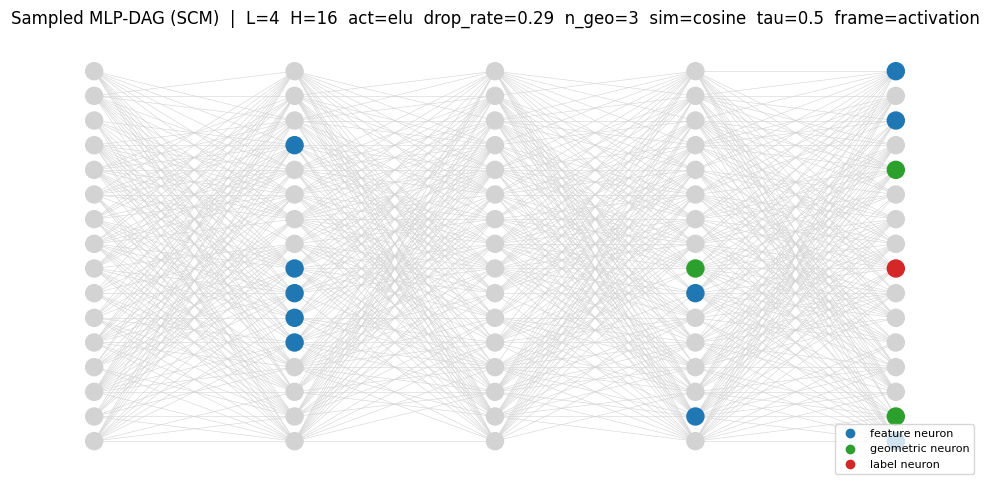

In [10]:
from matplotlib.lines import Line2D

def draw_scm_sim(
    scm: SCMGeo,
    similarity_name: str = 'cosine',
    threshold: float = SIM_THRESHOLD,
    frame: str = 'activation',
    title: str = 'Similarity-graph SCM DAG',
    ax: 'plt.Axes | None' = None,
) -> None:
    G = nx.DiGraph()
    pos = {}
    for ell in range(scm.n_layers + 1):
        for i in range(scm.hidden):
            node = (ell, i)
            G.add_node(node)
            pos[node] = (ell, -i)

    for ell, mask in enumerate(scm.masks):
        rows, cols = torch.nonzero(mask, as_tuple=True)
        for r, c in zip(rows.tolist(), cols.tolist()):
            G.add_edge((ell, c), (ell + 1, r))

    # Stored layer values are 0-indexed (0 -> math-layer 1). The diagram puts input noise in
    # column 0 and post-activation layer L in column L, so shift each stored layer by +1.
    feature_set = {(int(ell) + 1, int(i)) for ell, i in scm.feature_idx.tolist()}
    geo_set     = {(int(ell) + 1, int(i)) for ell, i in scm.geo_idx.tolist()}
    label_node  = (scm.n_layers, scm.label_idx)

    node_colors = []
    for node in G.nodes():
        if node in geo_set:
            node_colors.append('tab:green')
        elif node in feature_set:
            node_colors.append('tab:blue')
        elif node == label_node:
            node_colors.append('tab:red')
        else:
            node_colors.append('lightgray')

    owns_figure = ax is None
    if owns_figure:
        _, ax = plt.subplots(figsize=(10, 5))
    nx.draw(
        G, pos, node_color=node_colors, node_size=150,
        arrows=False, with_labels=False, edge_color='lightgray', width=0.4, ax=ax,
    )
    ax.set_title(
        f"{title}  |  L={scm.n_layers}  H={scm.hidden}  "
        f"act={scm.activation_name}  drop_rate={scm.drop_rate:.2f}  "
        f"n_geo={scm.geo_idx.shape[0]}  sim={similarity_name}  tau={threshold:g}  frame={frame}"
    )
    ax.set_xlabel('layer (input → output, left to right)')
    ax.set_xticks(list(range(scm.n_layers + 1)))
    handles = [
        Line2D([0], [0], marker='o', linestyle='', color='tab:blue',  label='feature neuron'),
        Line2D([0], [0], marker='o', linestyle='', color='tab:green', label='geometric neuron'),
        Line2D([0], [0], marker='o', linestyle='', color='tab:red',   label='label neuron'),
    ]
    ax.legend(handles=handles, loc='lower right', fontsize=8)
    if owns_figure:
        plt.tight_layout()
        plt.show()


# Quick look at one freshly-sampled SCM.
demo_scm = sample_scm_geo()
draw_scm_sim(demo_scm, title='Sampled MLP-DAG (SCM)')

**3b. Canonical example.** Headline mode: `similarity='cosine'`, `normalize='activation'` (the analytic correction), $n_\text{geo}=3$, $\tau=0.5$.

In [11]:
torch.manual_seed(7)
np.random.seed(7)

data = sample_geo_similarity_dataset(
    n_nodes=N_NODES_GRAPH,
    n_features=N_FEATURES,
    n_classes=N_CLASSES,
    n_geo=N_GEO,
    similarity='cosine',
    sim_threshold=0.5,
    normalize='activation',
)

A = data['A']
y = data['y']
Phi_f = data['Phi_framed']
S = data['S']
c = analytic_offsets(data['scm'])

avg_deg = float(A.sum(dim=1).mean())
Gnx_check = nx.from_numpy_array(A.numpy())
n_components = nx.number_connected_components(Gnx_check)
baseline_deg = (N_NODES_GRAPH - 1) * (1 - 0.5) / 2.0   # hat-box uniform-direction baseline

print(f'n_nodes        = {N_NODES_GRAPH}')
print(f'similarity     = {data["similarity"]}   tau = {data["sim_threshold"]}   '
      f'frame = {data["normalize"]}   activation = {data["scm"].activation_name}')
print(f'activation off = {c.numpy().round(3)}   ||c|| = {float(c.norm()):.3f}  '
      f'(0 for tanh/identity)')
print(f'avg degree     = {avg_deg:.2f}   (hat-box baseline ~ {baseline_deg:.1f}, log n = {math.log(N_NODES_GRAPH):.2f})')
print(f'#components    = {n_components}')
print(f'class sizes    = {torch.bincount(y).tolist()}')

n_nodes        = 64
similarity     = cosine   tau = 0.5   frame = activation   activation = leaky_relu
activation off = [0.061 0.054 0.078]   ||c|| = 0.113  (0 for tanh/identity)
avg degree     = 16.56   (hat-box baseline ~ 15.8, log n = 4.16)
#components    = 1
class sizes    = [19, 41, 4]


**3c. The SCM diagram for this draw.**

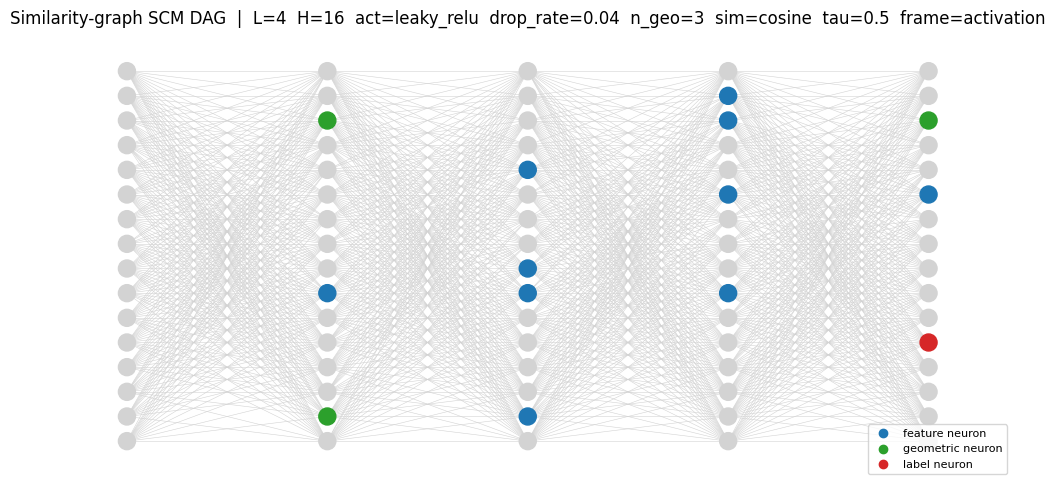

In [12]:
draw_scm_sim(data['scm'], similarity_name=data['similarity'],
             threshold=data['sim_threshold'], frame=data['normalize'])

**3d. The framed embedding as directions on the unit sphere, coloured by class.** Cosine thresholding connects nodes whose direction vectors lie within an angular cone ($\theta<60^\circ$ at $\tau=0.5$); angular clusters here become dense subgraphs. We plot $\Phi^{\mathrm f}/\lVert\Phi^{\mathrm f}\rVert$ (what cosine actually sees) together with a translucent unit sphere.

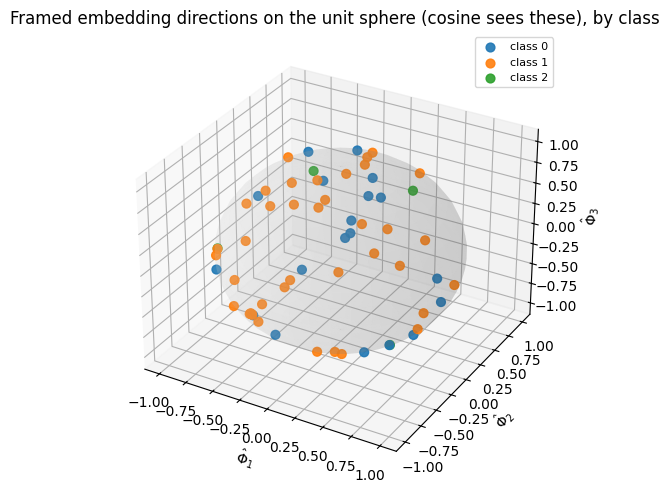

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

dirs = Phi_f / Phi_f.norm(dim=1, keepdim=True).clamp_min(1e-12)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
# translucent unit sphere for reference
u = np.linspace(0, 2 * np.pi, 40); v = np.linspace(0, np.pi, 20)
ax.plot_surface(np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                np.outer(np.ones_like(u), np.cos(v)), color='lightgray', alpha=0.12, linewidth=0)
for cc in range(N_CLASSES):
    sel = (y == cc).numpy()
    ax.scatter(dirs[sel, 0].numpy(), dirs[sel, 1].numpy(), dirs[sel, 2].numpy(),
               label=f'class {cc}', s=40, alpha=0.9)
ax.set_xlabel(r'$\hat\Phi_1$'); ax.set_ylabel(r'$\hat\Phi_2$'); ax.set_zlabel(r'$\hat\Phi_3$')
ax.set_title('Framed embedding directions on the unit sphere (cosine sees these), by class')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**3e. Resulting graph.** Left: adjacency sorted by class (block structure = label-homophily from the geometry). Right: force-directed layout coloured by class.

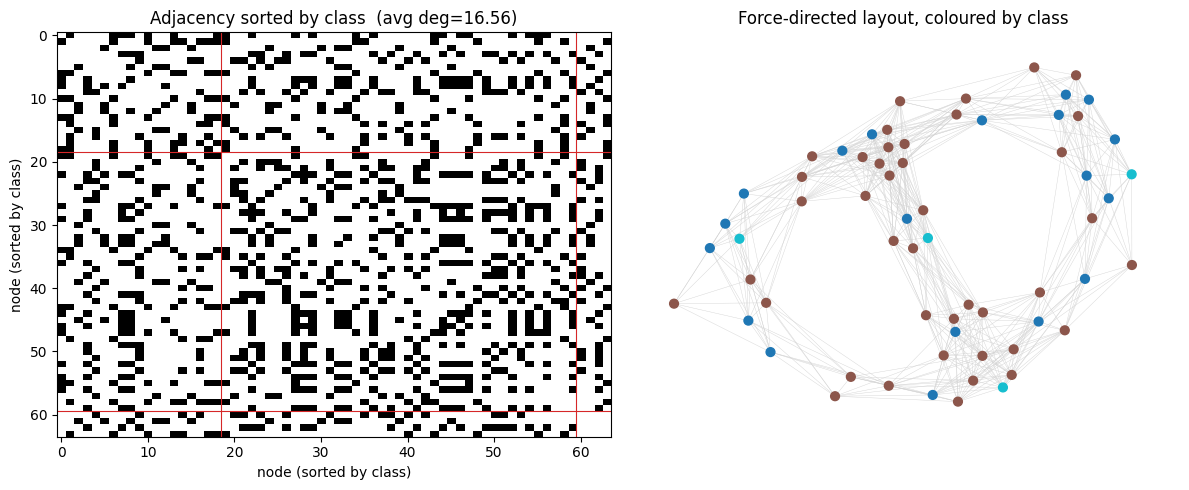

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = torch.argsort(y)
ax = axes[0]
ax.imshow(A[order][:, order].numpy(), cmap='Greys', interpolation='nearest', aspect='auto')
cum = 0
for cs in torch.bincount(y).tolist()[:-1]:
    cum += cs
    ax.axhline(cum - 0.5, color='tab:red', linewidth=0.8)
    ax.axvline(cum - 0.5, color='tab:red', linewidth=0.8)
ax.set_title(f'Adjacency sorted by class  (avg deg={avg_deg:.2f})')
ax.set_xlabel('node (sorted by class)'); ax.set_ylabel('node (sorted by class)')

Gnx = nx.from_numpy_array(A.numpy())
pos = nx.spring_layout(Gnx, seed=0)
ax = axes[1]
nx.draw(Gnx, pos, ax=ax, node_size=40, width=0.3, edge_color='lightgray',
        node_color=y.numpy(), cmap=plt.cm.tab10)
ax.set_title('Force-directed layout, coloured by class')
plt.tight_layout()
plt.show()

**3f. The similarity matrix and the threshold.** Left: histogram of the off-diagonal similarities with $\tau$ marked — edges are the mass to the *right* of the line. Right: the similarity matrix sorted by class (diverging colour map centred at $0$); brighter diagonal blocks indicate label-homophily.

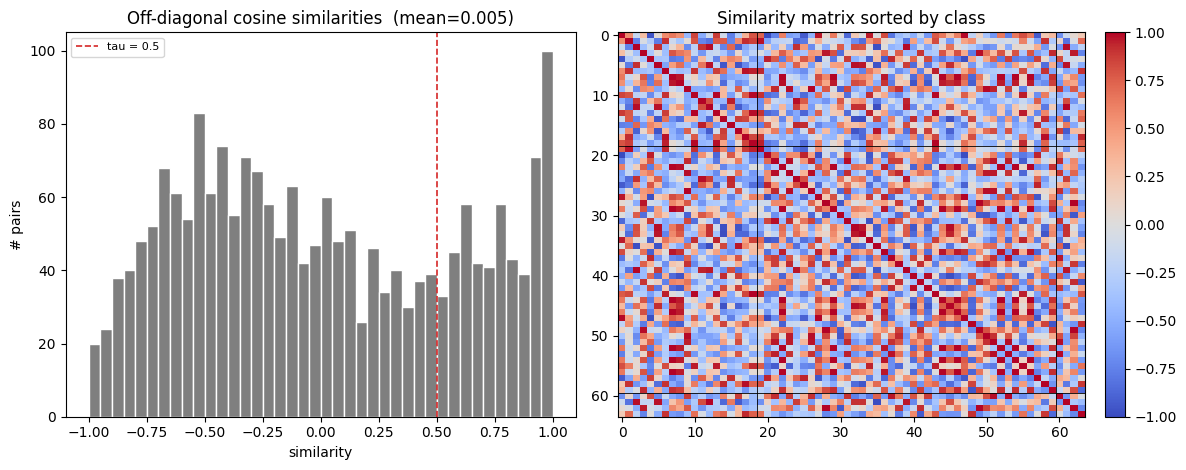

In [15]:
iu = torch.triu_indices(N_NODES_GRAPH, N_NODES_GRAPH, offset=1)
off = S[iu[0], iu[1]].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].hist(off, bins=40, range=(-1, 1), color='tab:gray', edgecolor='white')
axes[0].axvline(0.5, color='tab:red', linestyle='--', linewidth=1.2, label='tau = 0.5')
axes[0].set_title(f'Off-diagonal cosine similarities  (mean={off.mean():.3f})')
axes[0].set_xlabel('similarity'); axes[0].set_ylabel('# pairs'); axes[0].legend(fontsize=8)

Ssorted = S[order][:, order].numpy()
im = axes[1].imshow(Ssorted, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest', aspect='auto')
cum = 0
for cs in torch.bincount(y).tolist()[:-1]:
    cum += cs
    axes[1].axhline(cum - 0.5, color='k', linewidth=0.6)
    axes[1].axvline(cum - 0.5, color='k', linewidth=0.6)
axes[1].set_title('Similarity matrix sorted by class')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**3g. The activation-bias correction in action — corrected vs uncorrected.** For each activation we fix the *same* SCM weights/seed and only switch the activation, then compare the raw cosine similarities (`frame='none'`) against the analytically corrected ones (`frame='activation'`). Expect: **tanh/identity unchanged** (offset $\approx 0$, so the correction is a no-op); **leaky\_relu/elu** raw similarities piled near $+1$ — a near-complete graph at $\tau=0.5$ — and the correction spreading them back over $[-1,1]$. The printed table also checks the analytic offset $c$ against the empirical mean of $\Phi$ (the validation of the moment propagation in §1.5).

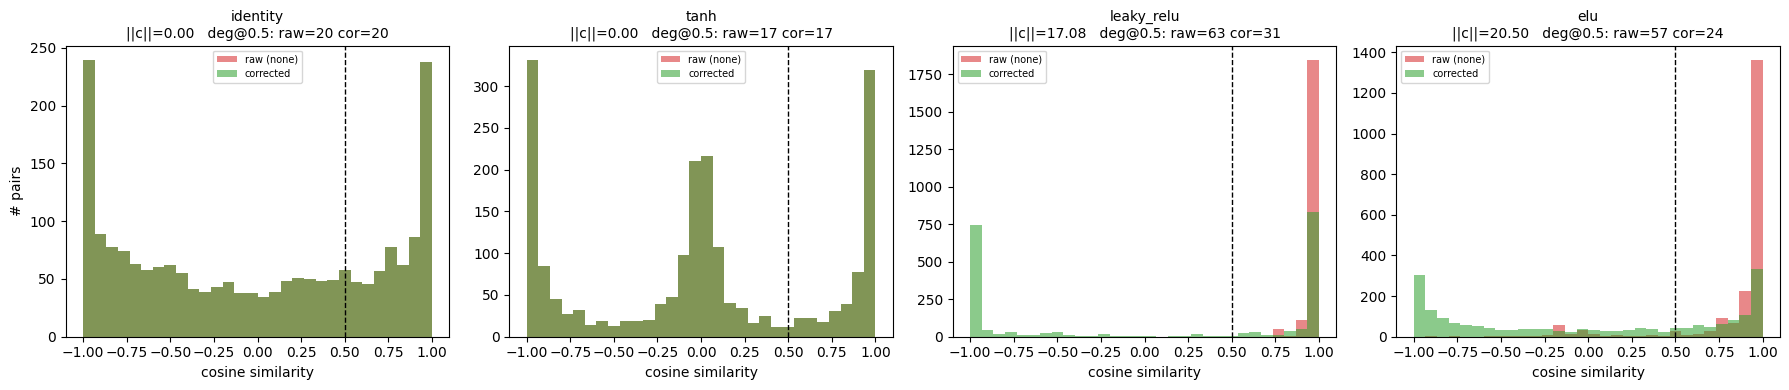

activation     ||c||  ||c-emp||  mean-cos raw  mean-cos cor  deg raw  deg cor
identity       0.000      2.331        -0.015        -0.015     20.1     20.1
tanh           0.000      0.086        -0.013        -0.013     16.8     16.8
leaky_relu    17.084      0.645         0.986         0.044     63.0     31.3
elu           20.497      2.977         0.847        -0.005     56.9     23.6


In [16]:
acts_to_show = ['identity', 'tanh', 'leaky_relu', 'elu']
iu = torch.triu_indices(N_NODES_GRAPH, N_NODES_GRAPH, offset=1)

def _deg_at(M, tau=0.5):
    Adj = (M > tau).float(); Adj.fill_diagonal_(0.0)
    return float(Adj.sum(dim=1).mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
rows = []
for ax, act in zip(axes, acts_to_show):
    torch.manual_seed(11); np.random.seed(11)
    scm = sample_scm_geo()
    scm.activation_name = act                      # override to isolate the activation effect
    _, _, Phi = forward_scm_geo(scm, N_NODES_GRAPH)
    c = analytic_offsets(scm)
    S_raw = cosine_sim(Phi, Phi)
    S_cor = cosine_sim(Phi - c.unsqueeze(0), Phi - c.unsqueeze(0))
    raw_o = S_raw[iu[0], iu[1]].numpy(); cor_o = S_cor[iu[0], iu[1]].numpy()

    ax.hist(raw_o, bins=30, range=(-1, 1), alpha=0.55, color='tab:red',   label='raw (none)')
    ax.hist(cor_o, bins=30, range=(-1, 1), alpha=0.55, color='tab:green', label='corrected')
    ax.axvline(0.5, color='k', linestyle='--', linewidth=1)
    ax.set_title(f"{act}\n||c||={float(c.norm()):.2f}   "
                 f"deg@0.5: raw={_deg_at(S_raw):.0f} cor={_deg_at(S_cor):.0f}", fontsize=10)
    ax.set_xlabel('cosine similarity'); ax.legend(fontsize=7)

    emp = Phi.mean(0)
    rows.append((act, float(c.norm()), float((c - emp).norm()),
                 float(raw_o.mean()), float(cor_o.mean()), _deg_at(S_raw), _deg_at(S_cor)))
axes[0].set_ylabel('# pairs')
plt.tight_layout()
plt.show()

print(f'{"activation":11s}{"||c||":>9s}{"||c-emp||":>11s}{"mean-cos raw":>14s}'
      f'{"mean-cos cor":>14s}{"deg raw":>9s}{"deg cor":>9s}')
for act, cn, dce, mr, mc, dr, dc in rows:
    print(f'{act:11s}{cn:9.3f}{dce:11.3f}{mr:14.3f}{mc:14.3f}{dr:9.1f}{dc:9.1f}')

**3g (cont.). The geometry behind the bias** — `elu` raw vs corrected. Left: the raw embedding $\Phi$ sits off-origin (the activation origin $\mathbf 0$ is marked $\times$), so almost every direction points the same way → cosines near $+1$. Right: after subtracting the analytic offset $c$, the cloud straddles the origin and directions span the sphere.

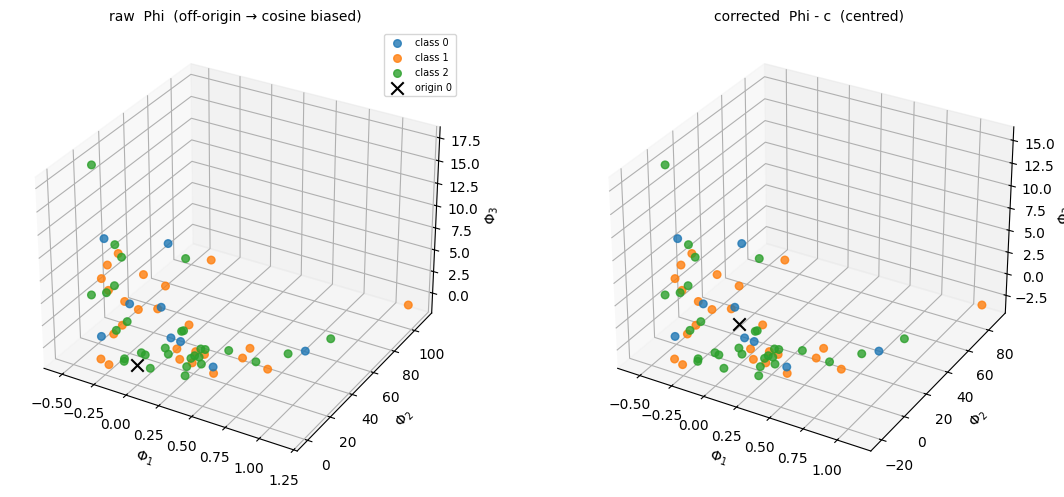

In [17]:
torch.manual_seed(11); np.random.seed(11)
scm = sample_scm_geo(); scm.activation_name = 'elu'
_, y_hat_e, Phi_e = forward_scm_geo(scm, N_NODES_GRAPH)
y_e, _ = discretise_labels(y_hat_e, n_classes=N_CLASSES)
c = analytic_offsets(scm)

fig = plt.figure(figsize=(12, 5))
for k, (ttl, P) in enumerate([('raw  Phi  (off-origin → cosine biased)', Phi_e),
                              ('corrected  Phi - c  (centred)', Phi_e - c)]):
    ax = fig.add_subplot(1, 2, k + 1, projection='3d')
    for cc in range(N_CLASSES):
        sel = (y_e == cc).numpy()
        ax.scatter(P[sel, 0].numpy(), P[sel, 1].numpy(), P[sel, 2].numpy(), s=30, alpha=0.8,
                   label=f'class {cc}')
    ax.scatter([0], [0], [0], marker='x', color='k', s=80, label='origin 0')
    ax.set_xlabel(r'$\Phi_1$'); ax.set_ylabel(r'$\Phi_2$'); ax.set_zlabel(r'$\Phi_3$')
    ax.set_title(ttl, fontsize=10)
    if k == 0:
        ax.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

**3h. Threshold sweep.** Same SCM/embedding (cosine, analytic frame); only $\tau$ changes. Raising $\tau$ narrows the angular cone, so the graph thins monotonically. Realised average degree is printed per panel; compare with the hat-box baseline $(n-1)(1-\tau)/2$.

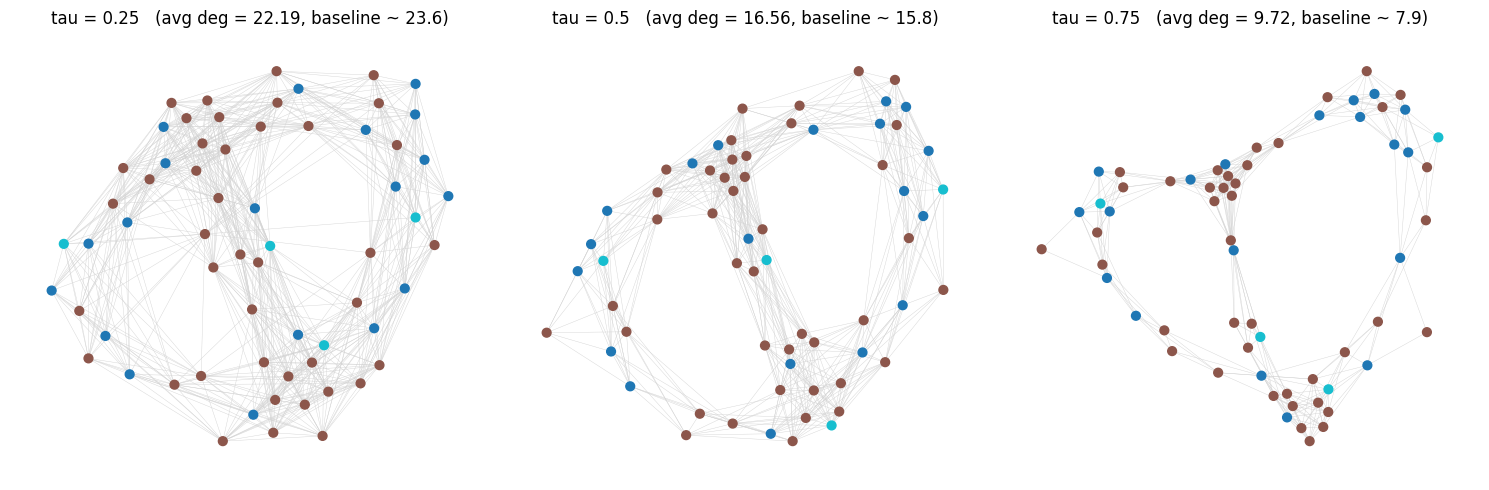

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tau in zip(axes, [0.25, 0.5, 0.75]):
    torch.manual_seed(7); np.random.seed(7)
    d = sample_geo_similarity_dataset(n_nodes=N_NODES_GRAPH, similarity='cosine',
                                      sim_threshold=tau, normalize='activation')
    A_s = d['A']; avg = float(A_s.sum(dim=1).mean())
    base = (N_NODES_GRAPH - 1) * (1 - tau) / 2.0
    Gnx = nx.from_numpy_array(A_s.numpy())
    pos = nx.spring_layout(Gnx, seed=0)
    nx.draw(Gnx, pos, ax=ax, node_size=40, width=0.3, edge_color='lightgray',
            node_color=d['y'].numpy(), cmap=plt.cm.tab10)
    ax.set_title(f'tau = {tau}   (avg deg = {avg:.2f}, baseline ~ {base:.1f})')
plt.tight_layout()
plt.show()

**3i. The three similarity measures.** Identical SCM/seed → identical features, labels, and embedding; only the *kernel* differs (cosine, then a random linear warp, then a random nonlinear feature map). For each we show the force layout and the degree distribution, and report average degree and the homophily ratio $P(\text{same})/P(\text{diff})$. The bilinear/MLP warps reshape the similarity distribution, so density and homophily shift even though $\Phi$ and $\tau$ are fixed.

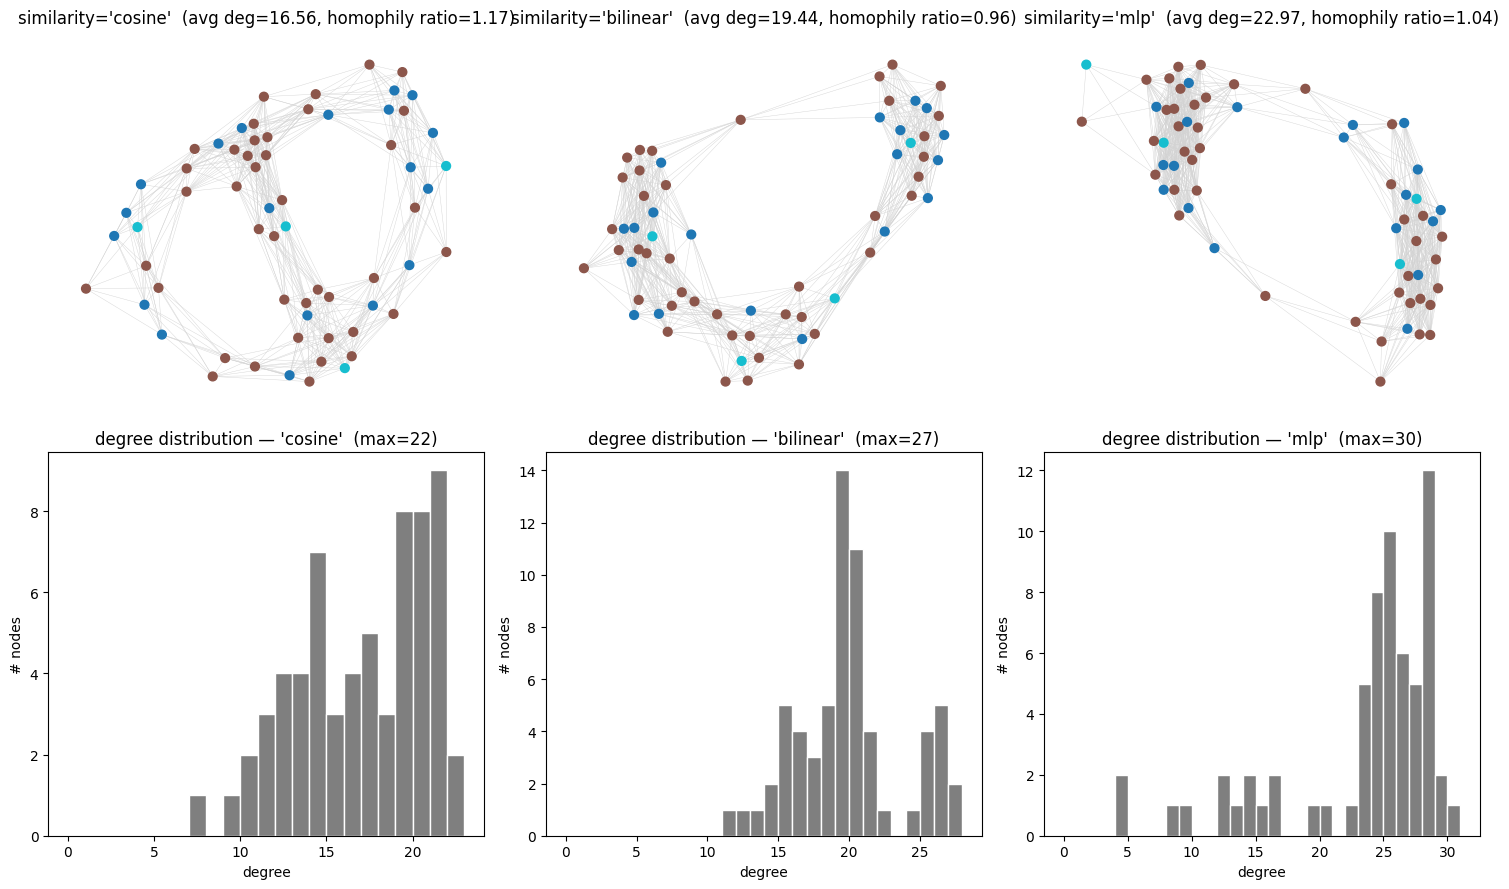

In [19]:
def homophily_ratio(A, y, C):
    Y = torch.nn.functional.one_hot(y, num_classes=C).float()
    M = Y.T @ A @ Y; total = float(M.sum())
    if total == 0: return float('nan')
    h = float(M.trace()) / total
    return h / (1 - h) if h < 1 else float('inf')

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, meas in enumerate(['cosine', 'bilinear', 'mlp']):
    torch.manual_seed(7); np.random.seed(7)
    d = sample_geo_similarity_dataset(n_nodes=N_NODES_GRAPH, similarity=meas,
                                      sim_threshold=0.5, normalize='activation')
    Am, ym = d['A'], d['y']; degm = Am.sum(dim=1); avgm = float(degm.mean())
    hr = homophily_ratio(Am, ym, N_CLASSES)

    Gm = nx.from_numpy_array(Am.numpy())
    pos = nx.spring_layout(Gm, seed=0)
    nx.draw(Gm, pos, ax=axes[0, col], node_size=40, width=0.3, edge_color='lightgray',
            node_color=ym.numpy(), cmap=plt.cm.tab10)
    axes[0, col].set_title(f"similarity='{meas}'  (avg deg={avgm:.2f}, homophily ratio={hr:.2f})")

    axes[1, col].hist(degm.numpy(), bins=range(int(degm.max().item()) + 2),
                      color='tab:gray', edgecolor='white')
    axes[1, col].set_title(f"degree distribution — '{meas}'  (max={int(degm.max())})")
    axes[1, col].set_xlabel('degree'); axes[1, col].set_ylabel('# nodes')
plt.tight_layout()
plt.show()

**3i (cont.). The random maps behind the kernels — weights $\to$ the similarity they induce.** Cosine is parameter-free, but `bilinear` and `mlp` each draw a random map *per dataset*, and that map **is** the similarity model. On the **same fixed embedding $\Phi$** (seed 7, so $\Phi$ is identical to §3i) we put the random weights on the left and the similarity matrix $S$ they produce on the right. **Top — bilinear:** the warp $L$ and the induced metric $M=L^\top L$ — the inner product $\langle a,b\rangle_M$ that cosine actually uses. **Bottom — MLP:** the per-layer weights $W_1,W_2$ of $\varphi$. Both $S$ are sorted by class; brighter diagonal blocks are label-homophily, and they differ from each other — and from plain cosine — purely because of these matrices.

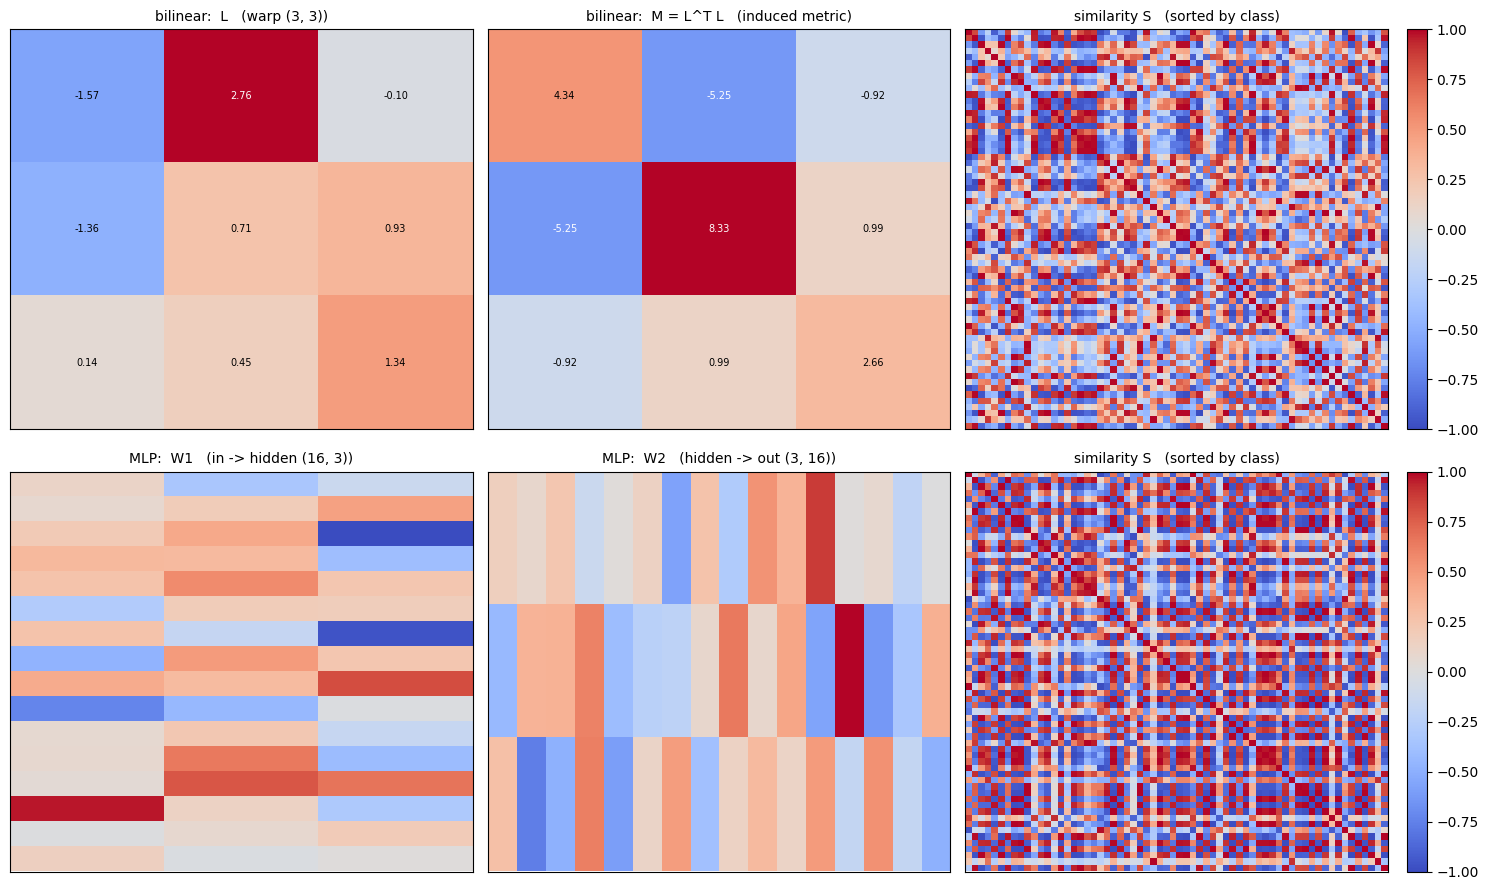

MLP feature activation = tanh   (similarity MLP supports symmetric/odd only: ['asinh', 'erf', 'identity', 'sin', 'tanh'])


In [20]:
# Same SCM/seed as 3i, so Phi is identical across kernels; only the random map differs.
def _heat(ax, Mtx, title, annotate=False, vmin=None, vmax=None):
    Mn = np.asarray(Mtx)
    if vmin is None or vmax is None:
        a = float(np.abs(Mn).max()) or 1.0
        vmin, vmax = -a, a
    im = ax.imshow(Mn, cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    if annotate:
        thr = 0.6 * max(abs(vmin), abs(vmax))
        for (i, j), v in np.ndenumerate(Mn):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > thr else 'black')
    return im

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Top: bilinear -- the random warp L and the metric M = L^T L it induces ---
torch.manual_seed(7); np.random.seed(7)
db = sample_geo_similarity_dataset(n_nodes=N_NODES_GRAPH, similarity='bilinear',
                                   sim_threshold=0.5, normalize='activation')
L = db['sim_params']['L']; M = L.T @ L
order = torch.argsort(db['y'])
_heat(axes[0, 0], L.numpy(), f'bilinear:  L   (warp {tuple(L.shape)})', annotate=True)
_heat(axes[0, 1], M.numpy(), 'bilinear:  M = L^T L   (induced metric)', annotate=True)
im = _heat(axes[0, 2], db['S'][order][:, order].numpy(),
           'similarity S   (sorted by class)', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

# --- Bottom: MLP -- the per-layer weights of phi (same Phi as the bilinear row) ---
torch.manual_seed(7); np.random.seed(7)
dm = sample_geo_similarity_dataset(n_nodes=N_NODES_GRAPH, similarity='mlp',
                                   sim_threshold=0.5, normalize='activation')
Ws = dm['sim_params']['weights']; order = torch.argsort(dm['y'])
_heat(axes[1, 0], Ws[0].numpy(), f'MLP:  W1   (in -> hidden {tuple(Ws[0].shape)})')
_heat(axes[1, 1], Ws[1].numpy(), f'MLP:  W2   (hidden -> out {tuple(Ws[1].shape)})')
im = _heat(axes[1, 2], dm['S'][order][:, order].numpy(),
           'similarity S   (sorted by class)', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

act = dm['sim_params']['act']
print(f'MLP feature activation = {act}   '
      f'(similarity MLP supports symmetric/odd only: {sorted(SYMMETRIC_ACTIVATIONS)})')

## 4. Interactive demo

The widget regenerates a fresh dataset and re-plots on every parameter change. Notes:

- **`similarity`** selects the kernel (`cosine` / `bilinear` / `mlp`); **`tau`** is the similarity threshold (connect when $\mathrm{sim}>\tau$); **`frame`** is the embedding frame and defaults to **`activation`** (the data-free activation-bias correction). Switch `frame` to `none` to *see* the bias (try a `leaky_relu`/`elu` draw), or to `minmax` to see the positive-orthant pathology.
- **`sim_out_dim`** sets the output dimension of the bilinear/MLP map (ignored for cosine). **`sim_act (MLP)`** picks the MLP kernel's symmetric (odd) feature activation — `tanh`/`sin`/`erf`/`asinh`/`identity` — and is **only active when `similarity='mlp'`** (greyed out otherwise).
- The **kernel-maps row** shows the random matrices that *define* the chosen similarity — `L` and the induced metric $M=L^\top L$ for `bilinear`, the layer weights $W_1,W_2$ for `mlp` — beside the similarity matrix $S$ they produce (cosine is parameter-free, so only $S$ is shown).
- The SCM has $L\cdot H$ post-activation neurons; we need $n_\text{features}+n_\text{geo}\le L\cdot H - 1$ (the label takes one slot). The widget surfaces a clear error if violated.

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [23]:
# --- Widgets ---
STYLE = {'description_width': '110px'}
LAYOUT = widgets.Layout(width='320px')

n_nodes_w    = widgets.IntSlider(value=64, min=16, max=256, step=8,  description='n_nodes',    style=STYLE, layout=LAYOUT, continuous_update=False)
n_features_w = widgets.IntSlider(value=10, min=2,  max=24,  step=1,  description='n_features', style=STYLE, layout=LAYOUT, continuous_update=False)
n_classes_w  = widgets.IntSlider(value=3,  min=2,  max=8,   step=1,  description='n_classes',  style=STYLE, layout=LAYOUT, continuous_update=False)
n_geo_w      = widgets.IntSlider(value=3,  min=2,  max=8,   step=1,  description='n_geo',      style=STYLE, layout=LAYOUT, continuous_update=False)
n_layers_w   = widgets.IntSlider(value=4,  min=2,  max=8,   step=1,  description='n_layers',   style=STYLE, layout=LAYOUT, continuous_update=False)
hidden_w     = widgets.IntSlider(value=16, min=4,  max=64,  step=4,  description='hidden (H)', style=STYLE, layout=LAYOUT, continuous_update=False)

drop_rate_w     = widgets.FloatSlider(value=0.5, min=0.0, max=0.9, step=0.01, description='dropout', style=STYLE, layout=LAYOUT, continuous_update=False, readout_format='.2f')
drop_isolated_w = widgets.Checkbox(value=False, description='drop isolated nodes (deg = 0)', style=STYLE, layout=widgets.Layout(width='320px'))

sim_w        = widgets.Dropdown(options=['cosine', 'bilinear', 'mlp'],               value='cosine',     description='similarity', style=STYLE, layout=LAYOUT)
frame_w      = widgets.Dropdown(options=['activation','none','center','minmax','zscore','rank'], value='activation', description='frame', style=STYLE, layout=LAYOUT)
tau_w        = widgets.FloatSlider(value=0.5, min=-1.0, max=1.0, step=0.02, description='tau', style=STYLE, layout=LAYOUT, continuous_update=False, readout_format='.2f')
sim_out_dim_w = widgets.IntSlider(value=3, min=1, max=32, step=1, description='sim_out_dim', style=STYLE, layout=LAYOUT, continuous_update=False)
sim_act_w    = widgets.Dropdown(options=sorted(SYMMETRIC_ACTIVATIONS), value='tanh', description='sim_act (MLP)', style=STYLE, layout=LAYOUT, disabled=True)

seed_w       = widgets.IntSlider(value=7,  min=0,  max=999, step=1,  description='seed',       style=STYLE, layout=LAYOUT, continuous_update=False)
layout_seed_w = widgets.IntText(value=0, description='layout seed', style=STYLE, layout=widgets.Layout(width='220px'))
resample_btn  = widgets.Button(description='resample layout', icon='refresh', layout=widgets.Layout(width='180px'))

out = widgets.Output()

def _draw():
    """Generate a dataset from the current widget values and render it into `out`."""
    torch.manual_seed(seed_w.value); np.random.seed(seed_w.value)
    C = int(n_classes_w.value)
    bar_colors = [plt.cm.tab10(j) for j in range(C)]
    try:
        d = sample_geo_similarity_dataset(
            n_nodes=n_nodes_w.value, n_features=n_features_w.value,
            n_classes=C, n_geo=n_geo_w.value,
            n_layers=n_layers_w.value, hidden=hidden_w.value,
            drop_rate=float(drop_rate_w.value),
            similarity=sim_w.value, sim_threshold=float(tau_w.value),
            normalize=frame_w.value, sim_out_dim=int(sim_out_dim_w.value),
            sim_act=sim_act_w.value,
        )
    except ValueError as e:
        with out:
            clear_output(wait=False)
            print(f'⚠  {e}')
        return

    A = d['A']; y = d['y']
    n_total = int(y.numel())

    keep = (A.sum(dim=1) > 0) if drop_isolated_w.value else torch.ones(n_total, dtype=torch.bool)
    A = A[keep][:, keep]; y = y[keep]
    S_show = d['S'][keep][:, keep]
    n_kept = int(y.numel())

    if n_kept == 0:
        with out:
            clear_output(wait=False)
            print(f'⚠  All {n_total} nodes are isolated; nothing to plot (lower tau or disable "drop isolated").')
        return

    deg = A.sum(dim=1); avg = float(deg.mean())
    Gnx = nx.from_numpy_array(A.numpy())
    n_comp = nx.number_connected_components(Gnx)
    layout_seed = int(layout_seed_w.value)

    # --- Class-mixing matrix M = Y.T A Y  and conditional q(j|c) = M[c,j] / sum_j M[c,j] ---
    Y = torch.nn.functional.one_hot(y, num_classes=C).float()
    M = Y.T @ A @ Y
    row_sums = M.sum(dim=1)
    safe_rows = row_sums.clamp_min(1.0).unsqueeze(1)
    P_nbr = M / safe_rows
    total = float(M.sum())
    if total > 0.0:
        h = float(M.trace()) / total
        h_bar = 1.0 - h
        ratio_str = '∞' if h_bar == 0 else f'{h / h_bar:.3f}'
        homophily_line = f'homophily  P(same)={h:.3f}  P(diff)={h_bar:.3f}  ratio={ratio_str}'
    else:
        homophily_line = 'homophily  n/a (no edges)'

    # --- Kernel-illustration panels: the random map(s) the similarity uses (none for cosine). ---
    sp = d['sim_params']; sim_name = d['similarity']
    if sim_name == 'bilinear':
        Lm = sp['L']
        kpanels = [(Lm.numpy(), f'L  (warp {tuple(Lm.shape)})', True),
                   ((Lm.T @ Lm).numpy(), 'M = L^T L  (metric)', True)]
    elif sim_name == 'mlp':
        kpanels = [(W.numpy(), f'W{i + 1}  {tuple(W.shape)}', False) for i, W in enumerate(sp['weights'])]
    else:
        kpanels = []   # cosine is parameter-free

    # --- Figure: SCM | graph+adjacency+degree | kernel maps + S | P(y) + q(·|c) bars ---
    fig = plt.figure(figsize=(13, 16))
    outer = fig.add_gridspec(4, 1, height_ratios=[1.0, 1.3, 1.0, 0.9])
    ax_scm = fig.add_subplot(outer[0])
    row2 = outer[1].subgridspec(1, 3)
    ax_graph = fig.add_subplot(row2[0])
    ax_adj   = fig.add_subplot(row2[1])
    ax_deg   = fig.add_subplot(row2[2])
    rowk = outer[2].subgridspec(1, len(kpanels) + 1)
    kernel_axes = [fig.add_subplot(rowk[j]) for j in range(len(kpanels))]
    ax_sim      = fig.add_subplot(rowk[len(kpanels)])
    row4 = outer[3].subgridspec(1, C + 1)
    ax_marginal = fig.add_subplot(row4[0])
    nbr_axes    = [fig.add_subplot(row4[i + 1]) for i in range(C)]

    draw_scm_sim(d['scm'], similarity_name=d['similarity'], threshold=d['sim_threshold'],
                 frame=d['normalize'], title='Sampled SCM', ax=ax_scm)

    pos = nx.spring_layout(Gnx, seed=layout_seed)
    node_colors = [bar_colors[int(c)] for c in y.tolist()]
    nx.draw(Gnx, pos, ax=ax_graph, node_size=40, width=0.3, edge_color='lightgray',
            node_color=node_colors)
    ax_graph.set_title(f'Force-directed layout (seed={layout_seed})')

    order = torch.argsort(y)
    ax_adj.imshow(A[order][:, order].numpy(), cmap='Greys', interpolation='nearest', aspect='auto')
    cum = 0
    for cs in torch.bincount(y).tolist()[:-1]:
        cum += cs
        ax_adj.axhline(cum - 0.5, color='tab:red', linewidth=0.8)
        ax_adj.axvline(cum - 0.5, color='tab:red', linewidth=0.8)
    ax_adj.set_title('Adjacency sorted by class')

    ax_deg.hist(deg.numpy(), bins=range(int(deg.max().item()) + 2), color='tab:gray', edgecolor='white')
    ax_deg.set_title(f'Degree dist (max={int(deg.max())})')
    ax_deg.set_xlabel('degree'); ax_deg.set_ylabel('# nodes')

    # Kernel maps (left) -> the similarity S they induce on this fixed embedding (right).
    for ax, (Mtx, ttl, ann) in zip(kernel_axes, kpanels):
        _heat(ax, Mtx, ttl, annotate=ann)
    imS = _heat(ax_sim, S_show[order][:, order].numpy(), f'similarity S — {sim_name}', vmin=-1, vmax=1)
    fig.colorbar(imS, ax=ax_sim, fraction=0.046, pad=0.04)
    if not kpanels:
        ax_sim.set_title(f'similarity S — {sim_name}  (parameter-free)')

    class_counts = torch.bincount(y, minlength=C).float()
    class_marginal = class_counts / max(int(class_counts.sum().item()), 1)
    ax_marginal.bar(range(C), class_marginal.numpy(), color=bar_colors)
    ax_marginal.set_title('P(y) — class marginal', fontsize=10)
    ax_marginal.set_xticks(range(C)); ax_marginal.set_ylim(0, 1)
    ax_marginal.set_xlabel('class', fontsize=8); ax_marginal.set_ylabel('probability', fontsize=8)

    for c, ax in enumerate(nbr_axes):
        if row_sums[c] < 1.0:
            ax.set_title(f'class {c} — no edges', fontsize=9)
            ax.set_xticks(range(C)); ax.set_ylim(0, 1)
            ax.set_xlabel('neighbour class', fontsize=8)
            continue
        ax.bar(range(C), P_nbr[c].numpy(), color=bar_colors)
        ax.set_title(f'q(·|c={c})', fontsize=10)
        ax.set_xticks(range(C)); ax.set_ylim(0, 1)
        ax.set_xlabel('neighbour class', fontsize=8)

    fig.tight_layout()
    plt.close(fig)

    sim_act_str = sim_act_w.value if sim_name == 'mlp' else 'n/a'
    with out:
        clear_output(wait=False)
        print(f'similarity={d["similarity"]}   tau={d["sim_threshold"]:.2f}   frame={d["normalize"]}   '
              f'act={d["scm"].activation_name}   sim_out_dim={int(sim_out_dim_w.value)}   sim_act={sim_act_str}')
        print(f'avg deg={avg:.2f}   #components={n_comp}   nodes={n_kept}/{n_total}   '
              f'classes={torch.bincount(y).tolist()}')
        print(homophily_line)
        display(fig)

# --- Observers: any change to a value-bearing widget redraws; the button bumps layout_seed. ---
_value_widgets = [
    n_nodes_w, n_features_w, n_classes_w, n_geo_w, n_layers_w, hidden_w,
    drop_rate_w, drop_isolated_w, sim_w, frame_w, tau_w, sim_out_dim_w, sim_act_w, seed_w, layout_seed_w,
]
for _w in _value_widgets:
    _w.observe(lambda *_: _draw(), names='value')

# sim_act applies only to the MLP kernel; grey it out for cosine/bilinear.
def _toggle_sim_act(*_):
    sim_act_w.disabled = (sim_w.value != 'mlp')
sim_w.observe(_toggle_sim_act, names='value')
_toggle_sim_act()
resample_btn.on_click(lambda _: setattr(layout_seed_w, 'value', (layout_seed_w.value + 1) % 10_000))

ui = widgets.VBox([
    widgets.HBox([n_nodes_w, n_features_w, n_classes_w]),
    widgets.HBox([n_geo_w,   n_layers_w,   hidden_w]),
    widgets.HBox([drop_rate_w, drop_isolated_w]),
    widgets.HBox([sim_w,     frame_w,      tau_w]),
    widgets.HBox([sim_out_dim_w, sim_act_w, seed_w]),
    widgets.HBox([resample_btn, layout_seed_w]),
])
display(widgets.VBox([ui, out]))
_draw()   # initial render

## 5. Closing remarks

Recap of what the similarity-threshold geometric prior does differently:

- **Topology from a kernel, not a metric.** Step 7 becomes $\mathrm{sim}(\Phi^{\mathrm f}_u,\Phi^{\mathrm f}_v) > \tau$. The **cosine** (pure angle), **bilinear** (random linear warp, cosine under a random metric $M=L^\top L$), and **MLP** (cosine in a random nonlinear feature space) kernels are increasingly expressive sources of topology randomness, layered on top of and independent of the SCM.
- **The origin is a modelling object.** Similarities are translation-sensitive, so where the embedding sits matters. With **no normalisation** we keep the SCM's native geometry and instead remove the bias one-sided activations inject — *analytically*, from the known activation, via Gauss–Hermite moment propagation (§1.5). It is data-free, a no-op for tanh/identity, and preserves per-axis scale (unlike z-score). §3g shows it turning a degenerate near-complete graph (raw `leaky_relu`/`elu`) back into a meaningful one.
- **Emergent homophily, no knob.** As in the distance variants, $\Phi$ shares ancestors with $X$ and $y$, so feature- and label-homophily appear without a homophily hyperparameter; the kernel choice modulates how strongly.

Useful follow-ups for the reader:

- Retune $\tau$ for $n_\text{geo}\ne 3$ (pairwise cosine concentrates near $0$ as $n_\text{geo}$ grows) or to target $\sim\log n$ degree via $\tau\approx 1-2\log n/(n-1)$.
- Sweep the bilinear/MLP `sim_out_dim` (random projection vs lift) and the MLP depth/activation to see how the kernel's expressivity reshapes neighbourhoods.
- Compare frames on a one-sided-activation draw (`none` vs `activation` vs `center`) to see the bias and its corrections side by side.
- Mix this similarity prior 50/50 with conventional ER / cSBM (or the distance-based geometric) priors for a training distribution that covers several topology families.

In [30]:
# =====================================================================
# Bulk sampler: 100,000 cosine-similarity graphs whose hyperparameters
# are drawn i.i.d. from UNIFORM distributions over the dashboard ranges.
# Similarity is fixed to 'cosine'; the master seed makes the run reproducible.
#
# NOTE: dense uint8 adjacencies for 100k graphs use ~1-2 GB of RAM.
# Lower N_GRAPHS if memory is tight.
# =====================================================================
from tqdm.auto import tqdm

N_GRAPHS    = 100_000
MASTER_SEED = 0
SIMILARITY  = 'cosine'                      # fixed, as requested
FRAME_CHOICES = ['activation', 'none', 'center', 'minmax', 'zscore', 'rank']

hp_rng = np.random.default_rng(MASTER_SEED)  # independent stream for hyperparameters

def sample_hparams(rng):
    """One hyperparameter config, each entry drawn uniformly over its widget range."""
    return dict(
        n_nodes       = int(rng.integers(16 // 8, 256 // 8 + 1)) * 8,  # multiples of 8 in [16, 256]
        n_features    = int(rng.integers(2, 24 + 1)),                  # [2, 24]
        n_classes     = int(rng.integers(2, 8 + 1)),                   # [2, 8]
        n_geo         = int(rng.integers(2, 8 + 1)),                   # [2, 8]
        n_layers      = int(rng.integers(2, 8 + 1)),                   # [2, 8]
        hidden        = int(rng.integers(4 // 4, 64 // 4 + 1)) * 4,    # multiples of 4 in [4, 64]
        drop_rate     = float(rng.uniform(0.0, 0.9)),                  # [0.0, 0.9]
        drop_isolated = bool(rng.integers(0, 2)),                      # {False, True}
        frame         = str(rng.choice(FRAME_CHOICES)),                # uniform over frames
        tau           = float(rng.uniform(-1.0, 1.0)),                 # [-1.0, 1.0]
    )

def valid(hp):
    # sample_scm_geo requires: n_features + n_geo <= n_layers * hidden - 1
    return hp['n_features'] + hp['n_geo'] <= hp['n_layers'] * hp['hidden'] - 1

graphs = []        # each: {'A': uint8 adjacency, 'y': int16 labels, 'hp': dict}
for i in tqdm(range(N_GRAPHS), desc='sampling graphs'):
    hp = sample_hparams(hp_rng)
    while not valid(hp):                     # re-draw until the SCM constraint holds
        hp = sample_hparams(hp_rng)

    # deterministic per-graph seed for the SCM/forward/sim internals -> fully reproducible
    torch.manual_seed(MASTER_SEED + i)
    np.random.seed((MASTER_SEED + i) % (2 ** 32))

    d = sample_geo_similarity_dataset(
        n_nodes=hp['n_nodes'], n_features=hp['n_features'],
        n_classes=hp['n_classes'], n_geo=hp['n_geo'],
        n_layers=hp['n_layers'], hidden=hp['hidden'],
        drop_rate=hp['drop_rate'],
        similarity=SIMILARITY, sim_threshold=hp['tau'],
        normalize=hp['frame'],
    )
    A, y = d['A'], d['y']
    if hp['drop_isolated']:                  # optionally remove degree-0 nodes
        keep = A.sum(dim=1) > 0
        A = A[keep][:, keep]; y = y[keep]

    graphs.append({
        'A':  A.to(torch.uint8).cpu().numpy(),
        'y':  y.to(torch.int16).cpu().numpy(),
        'hp': hp,
    })

n_nodes_arr = np.array([g['A'].shape[0] for g in graphs])
print(f'generated {len(graphs):,} cosine-similarity graphs  (master seed = {MASTER_SEED})')
print(f'nodes per graph : min={n_nodes_arr.min()}  mean={n_nodes_arr.mean():.1f}  max={n_nodes_arr.max()}')

sampling graphs:   0%|          | 0/100000 [00:00<?, ?it/s]

generated 100,000 cosine-similarity graphs  (master seed = 0)
nodes per graph : min=0  mean=135.4  max=256


avg degree:   0%|          | 0/100000 [00:00<?, ?it/s]

homophily:   0%|          | 0/100000 [00:00<?, ?it/s]

assortativity:   0%|          | 0/100000 [00:00<?, ?it/s]

clustering + distance (n=2000):   0%|          | 0/2000 [00:00<?, ?it/s]


=== Assessment of 100,000 graphs  (subsample=2000) ===
Avg. degree                mean= 87.3552  std=66.4107  min= 0.0000  median=72.0682  max=255.0000  (n=99904)
Clustering coefficient     mean=  0.8497  std= 0.1812  min= 0.0000  median= 0.9048  max= 1.0000  (n=1998)
Avg. pairwise distance     mean=  1.5358  std= 0.8939  min= 1.0000  median= 1.2519  max=13.1458  (n=1994)
Homophily (edge frac.)     mean=  0.4057  std= 0.2011  min= 0.0000  median= 0.3526  max= 1.0000  (n=99799)
Assortativity (degree)     mean=  0.2671  std= 0.3421  min=-1.0000  median= 0.1656  max= 1.0000  (n=79483)
MMD degree     (half vs half) = 1.917363e-03
MMD clustering (half vs half) = 5.022861e-04


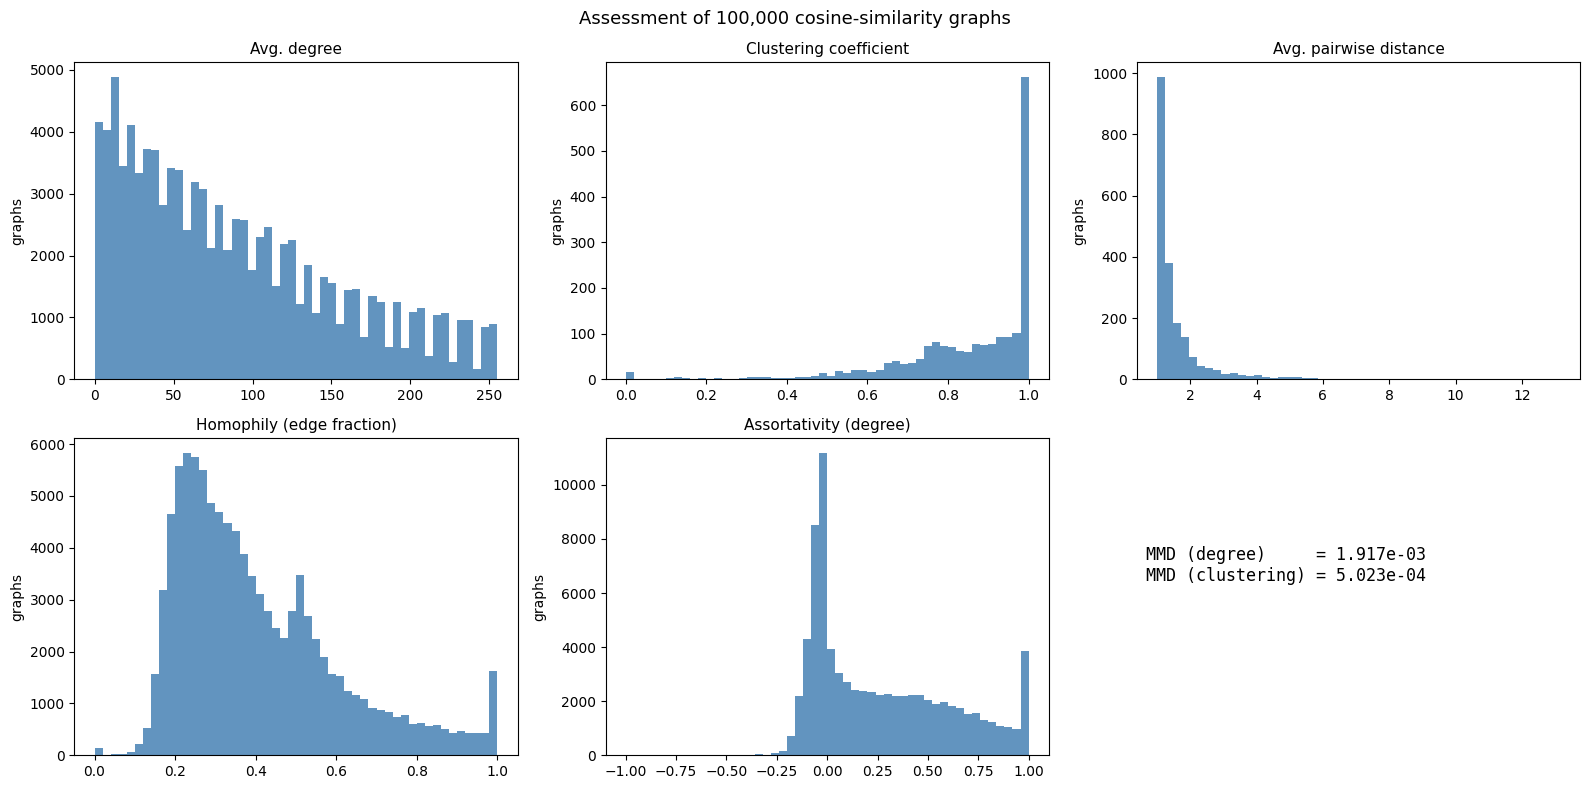

In [ ]:
# =====================================================================
# Assess the generated graphs.
#   Vectorized over ALL graphs     : avg degree, homophily, assortativity
#   networkx, on a fixed SUBSAMPLE : clustering coefficient, avg pairwise distance
#   MMD (RBF over histograms)      : degree & clustering, two random halves
# =====================================================================
import networkx as nx

SUBSAMPLE  = 2000     # graphs used for the O(n*m) networkx metrics
MMD_HALF   = 500      # graphs per side for the half-vs-half MMD check
metric_rng = np.random.default_rng(MASTER_SEED)

# ---- vectorized metrics (all graphs) ----
def avg_degree(A):
    n = A.shape[0]
    return A.sum() / n if n else np.nan            # A symmetric 0/1 -> sum=2|E|, mean deg=2|E|/n

def edge_homophily(A, y):
    iu = np.triu_indices_from(A, k=1)
    e  = A[iu] > 0
    m  = int(e.sum())
    if m == 0: return np.nan
    return int(((y[iu[0]] == y[iu[1]]) & e).sum()) / m   # fraction of edges joining same-class nodes

# High-degree node always connects to low-degree nodes -> r < 0. High-degree node always connects to high-degree nodes -> r > 0.
def degree_assortativity(A):
    iu = np.triu_indices_from(A, k=1)
    e  = A[iu] > 0
    src, dst = iu[0][e], iu[1][e]
    if src.size == 0: return np.nan
    deg = A.sum(1).astype(float) 
    x = np.concatenate([deg[src], deg[dst]])       # both endpoint orderings
    z = np.concatenate([deg[dst], deg[src]])
    if x.std() == 0 or z.std() == 0: return np.nan
    return float(np.corrcoef(x, z)[0, 1])

avg_deg = np.array([avg_degree(g['A'])             for g in tqdm(graphs, desc='avg degree')])
homoph  = np.array([edge_homophily(g['A'], g['y']) for g in tqdm(graphs, desc='homophily')])
assort  = np.array([degree_assortativity(g['A'])   for g in tqdm(graphs, desc='assortativity')])

# ---- expensive metrics on a fixed subsample ----
idx = metric_rng.choice(len(graphs), size=min(SUBSAMPLE, len(graphs)), replace=False)
clustering, avg_dist = [], []
for j in tqdm(idx, desc=f'clustering + distance (n={len(idx)})'):
    A = graphs[j]['A']
    if A.shape[0] == 0:
        clustering.append(np.nan); avg_dist.append(np.nan); continue
    G = nx.from_numpy_array(A.astype(float))
    clustering.append(nx.average_clustering(G))
    if G.number_of_edges():
        comp = G.subgraph(max(nx.connected_components(G), key=len))   # avg over largest component
        avg_dist.append(nx.average_shortest_path_length(comp) if comp.number_of_nodes() > 1 else 0.0)
    else:
        avg_dist.append(np.nan)
clustering = np.array(clustering); avg_dist = np.array(avg_dist)

# ---- Maximum Mean Discrepancy (RBF kernel over per-graph histograms) ----
def _hist(vals, bins):
    h, _ = np.histogram(vals, bins=bins)
    s = h.sum()
    return h / s if s else h.astype(float)

def descriptors(gs, kind, bins):
    out = []
    for g in gs:
        A = g['A']
        if kind == 'degree':
            out.append(_hist(A.sum(1), bins))
        else:                                       # clustering
            G = nx.from_numpy_array(A.astype(float))
            out.append(_hist(list(nx.clustering(G).values()) or [0.0], bins))
    return np.asarray(out, dtype=float)

def mmd_rbf(X, Y):
    """Biased MMD^2 with a Gaussian kernel; bandwidth via the median heuristic."""
    Z  = np.vstack([X, Y])
    sq = (Z ** 2).sum(1)
    d2 = np.maximum(sq[:, None] + sq[None, :] - 2 * Z @ Z.T, 0.0)
    sigma2 = np.median(d2[d2 > 0]) / 2 if np.any(d2 > 0) else 1.0
    K  = np.exp(-d2 / (2 * sigma2))
    n  = len(X)
    return float(K[:n, :n].mean() + K[n:, n:].mean() - 2 * K[:n, n:].mean())

mmd_idx = metric_rng.choice(len(graphs), size=min(2 * MMD_HALF, len(graphs)), replace=False)
half = len(mmd_idx) // 2
ga = [graphs[k] for k in mmd_idx[:half]]
gb = [graphs[k] for k in mmd_idx[half:]]
deg_bins, clu_bins = np.arange(0, 257), np.linspace(0, 1, 21)
mmd_deg = mmd_rbf(descriptors(ga, 'degree', deg_bins),     descriptors(gb, 'degree', deg_bins))
mmd_clu = mmd_rbf(descriptors(ga, 'clustering', clu_bins), descriptors(gb, 'clustering', clu_bins))

# ---- report ----
def _stats(name, a):
    a = a[np.isfinite(a)]
    print(f'{name:<26} mean={a.mean():8.4f}  std={a.std():7.4f}  '
        f'min={a.min():7.4f}  median={np.median(a):7.4f}  max={a.max():7.4f}  (n={a.size})')

print(f'\n=== Assessment of {len(graphs):,} graphs  (subsample={len(idx)}) ===')
_stats('Avg. degree',            avg_deg)
_stats('Clustering coefficient', clustering)
_stats('Avg. pairwise distance', avg_dist)
_stats('Homophily (edge frac.)', homoph)
_stats('Assortativity (degree)', assort)
print(f'MMD degree     (half vs half) = {mmd_deg:.6e}')
print(f'MMD clustering (half vs half) = {mmd_clu:.6e}')

# ---- distributions ----
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
panels = [('Avg. degree', avg_deg), ('Clustering coefficient', clustering),
        ('Avg. pairwise distance', avg_dist), ('Homophily (edge fraction)', homoph),
        ('Assortativity (degree)', assort)]
for ax, (name, a) in zip(axes.ravel(), panels):
    ax.hist(a[np.isfinite(a)], bins=50, color='steelblue', alpha=0.85)
    ax.set_title(name, fontsize=11); ax.set_ylabel('graphs')
axes.ravel()[-1].axis('off')
axes.ravel()[-1].text(0.02, 0.55,
    f'MMD (degree)     = {mmd_deg:.3e}\nMMD (clustering) = {mmd_clu:.3e}',
    family='monospace', fontsize=12, transform=axes.ravel()[-1].transAxes)
fig.suptitle(f'Assessment of {len(graphs):,} cosine-similarity graphs', fontsize=13)
fig.tight_layout(); plt.show()

pooling degrees:   0%|          | 0/100000 [00:00<?, ?it/s]

=== Degree distribution: power law vs Poisson ===
  pooled degrees (>0)     : 13,449,448   mean=113.009  var=4969.120   (Poisson => var==mean)
  power-law fit (x>=xmin) : alpha=3.120   x_min=103   tail n=6,944,238   KS=0.1642
  Poisson fit  (tail MLE) : lambda=170.260
  Vuong LR (PL - Poisson) : R=28405249.7   norm-stat=2020.10   p=0
  VERDICT                 : POWER LAW favoured
  (Note: KS<~0.05 + alpha in [2,3] => credible power law; var~=mean => Poisson-like.)


all-pairs shortest paths (n=2000):   0%|          | 0/2000 [00:00<?, ?it/s]


=== Shortest-path geometry  (subsample=2000 graphs) ===
  pooled mean pairwise distance (reachable) = 1.537
  Char. path length (per G)  mean=  1.544  median=  1.256  min=  1.000  max= 12.315
  Diameter (per G)           mean=  2.889  median=  2.000  min=  1.000  max= 36.000
  Global efficiency          mean=  0.772  median=  0.833  min=  0.000  max=  1.000
  Reachable-pair fraction    mean=  0.935  median=  1.000  min=  0.000  max=  1.000


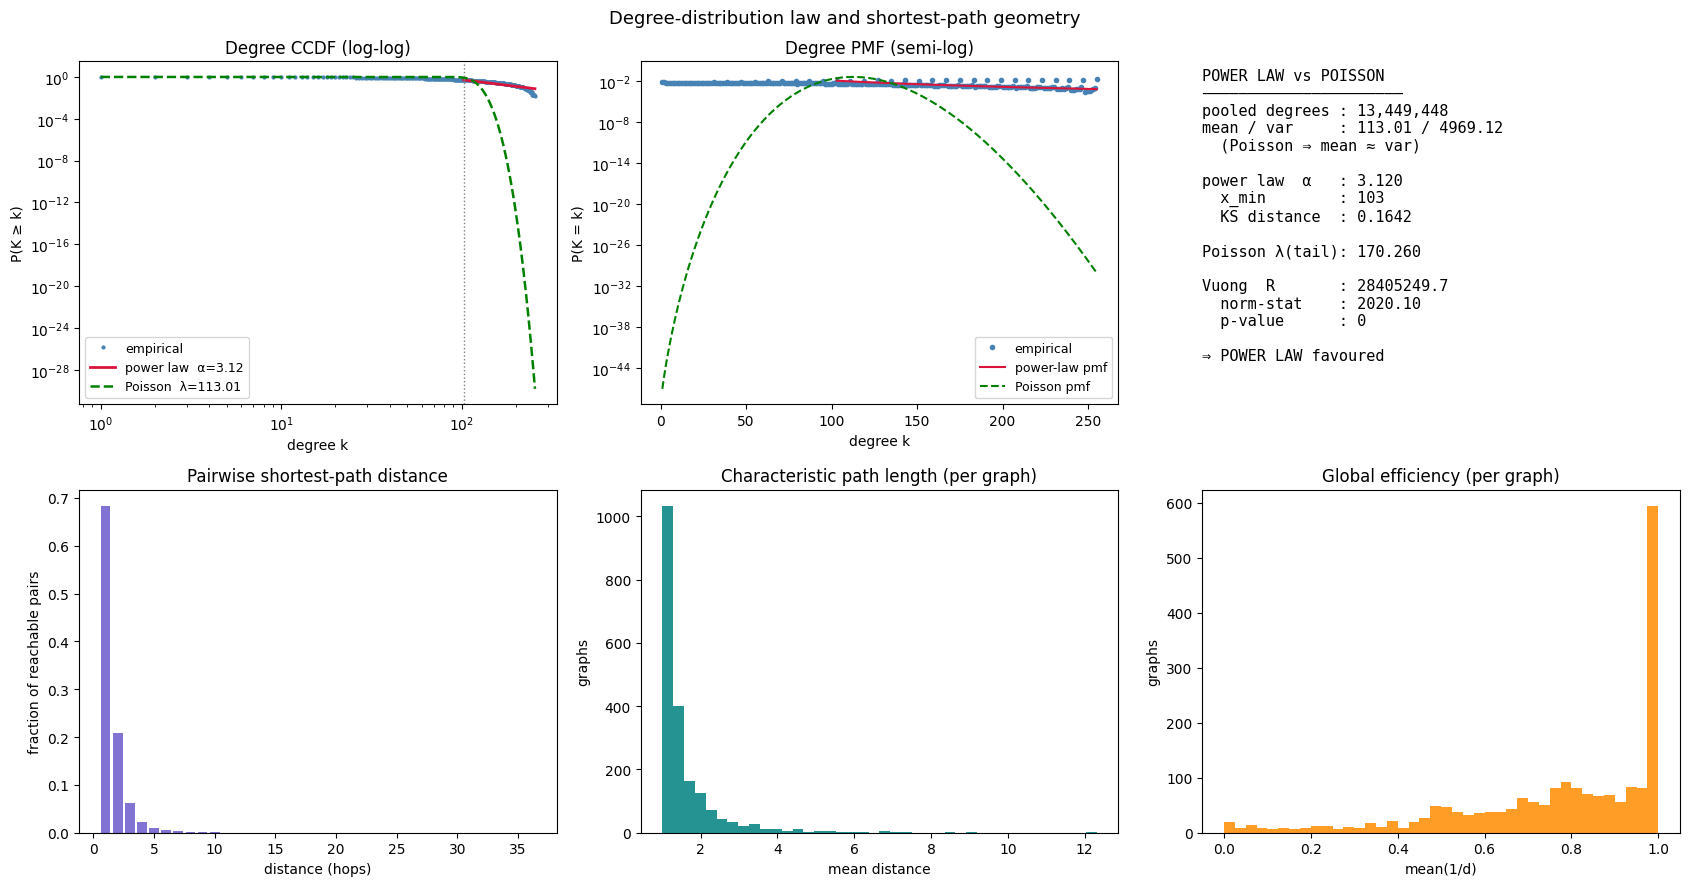

In [32]:
# =====================================================================
# Degree-distribution LAW  +  all-pairs SHORTEST-PATH geometry
#   (1) Is the pooled degree distribution a power law or a Poisson?
#         - discrete power-law MLE (Clauset-Shalizi-Newman), x_min via KS
#         - Poisson MLE on the same tail
#         - Vuong likelihood-ratio test: power law vs Poisson
#   (2) Shortest-path metric: the full all-pairs distance distribution,
#       characteristic path length, diameter, global efficiency, reach.
# Reuses `graphs`, `MASTER_SEED`, `tqdm`, `np`, `plt` from the cells above.
# =====================================================================
from scipy.special import zeta as _hzeta, erfc as _erfc   # zeta(a,q)=sum_{n>=q} n^-a
from scipy import stats as _st, optimize as _opt
from scipy.sparse import csr_matrix as _csr
from scipy.sparse.csgraph import shortest_path as _sp

# =====================================================================
# (1) DEGREE DISTRIBUTION  ---  power law vs Poisson
# =====================================================================
deg = np.concatenate([g['A'].sum(1).astype(np.int64)
                      for g in tqdm(graphs, desc='pooling degrees')])
deg = deg[deg > 0]                       # the law concerns the positive tail
deg_sorted = np.sort(deg)
N_deg = deg.size

def _tail(xmin):                         # tail observations  x >= xmin
    return deg_sorted[np.searchsorted(deg_sorted, xmin, side='left'):]

# ---- discrete power law:  p(x) = x^-alpha / zeta(alpha, xmin),  x >= xmin ----
def _pl_loglik(alpha, t, xmin):
    return -alpha * np.log(t).sum() - t.size * np.log(_hzeta(alpha, xmin))

def _fit_alpha(t, xmin):                 # MLE for the exponent
    return _opt.minimize_scalar(lambda a: -_pl_loglik(a, t, xmin),
                                bounds=(1.01, 6.0), method='bounded').x

def _ks(t, xmin, alpha):                 # KS distance, empirical vs fitted CDF
    xs = np.arange(xmin, int(t.max()) + 1)
    cdf_fit = 1.0 - _hzeta(alpha, xs + 1) / _hzeta(alpha, xmin)
    start = np.searchsorted(deg_sorted, xmin, side='left')
    cdf_emp = (np.searchsorted(deg_sorted, xs, side='right') - start) / t.size
    return np.abs(cdf_emp - cdf_fit).max()

# choose x_min by minimising KS over candidate values (Clauset et al. 2009)
cands = np.unique(deg)
cands = cands[(cands >= 1) & (cands <= np.quantile(deg, 0.90))]
fits = [(xm, _fit_alpha(_tail(xm), xm)) for xm in cands]
pl_xmin, pl_alpha = min(fits, key=lambda xa: _ks(_tail(xa[0]), xa[0], xa[1]))
tail = _tail(pl_xmin)
pl_D = _ks(tail, pl_xmin, pl_alpha)

# ---- Poisson, MLE on the SAME tail (truncated & renormalised to x>=xmin) ----
def _pois_tail_loglik(lam, t, xmin):
    logsf = np.log(_st.poisson.sf(xmin - 1, lam) + 1e-300)
    return (_st.poisson.logpmf(t, lam) - logsf).sum()

lam_tail = _opt.minimize_scalar(lambda L: -_pois_tail_loglik(L, tail, pl_xmin),
                                bounds=(1e-3, float(tail.max())), method='bounded').x
lam_full = deg.mean()                    # plain Poisson rate over the whole distribution

# ---- Vuong likelihood-ratio test on the tail:  power law vs Poisson ----
_logsf  = np.log(_st.poisson.sf(pl_xmin - 1, lam_tail) + 1e-300)
li_pl   = -pl_alpha * np.log(tail) - np.log(_hzeta(pl_alpha, pl_xmin))   # per-obs log-lik
li_pois = _st.poisson.logpmf(tail, lam_tail) - _logsf
d_ll    = li_pl - li_pois
R       = d_ll.sum()                     # >0 favours power law, <0 favours Poisson
sigma   = d_ll.std()
n_stat  = R / (np.sqrt(tail.size) * sigma) if sigma > 0 else 0.0
p_vuong = float(_erfc(abs(n_stat) / np.sqrt(2)))

if p_vuong < 0.10:
    verdict = 'POWER LAW favoured' if R > 0 else 'POISSON favoured'
else:
    verdict = 'inconclusive (neither clearly preferred)'

print('=== Degree distribution: power law vs Poisson ===')
print(f'  pooled degrees (>0)     : {N_deg:,}   mean={lam_full:.3f}  var={deg.var():.3f}'
      f'   (Poisson => var==mean)')
print(f'  power-law fit (x>=xmin) : alpha={pl_alpha:.3f}   x_min={pl_xmin}'
      f'   tail n={tail.size:,}   KS={pl_D:.4f}')
print(f'  Poisson fit  (tail MLE) : lambda={lam_tail:.3f}')
print(f'  Vuong LR (PL - Poisson) : R={R:.1f}   norm-stat={n_stat:.2f}   p={p_vuong:.3g}')
print(f'  VERDICT                 : {verdict}')
print(f'  (Note: KS<~0.05 + alpha in [2,3] => credible power law;'
      f' var~=mean => Poisson-like.)')

# =====================================================================
# (2) SHORTEST-PATH GEOMETRY  ---  all-pairs distances
# =====================================================================
SP_SUBSAMPLE = 2000
sp_rng = np.random.default_rng(MASTER_SEED + 1)
sp_idx = sp_rng.choice(len(graphs), size=min(SP_SUBSAMPLE, len(graphs)), replace=False)

dist_hist = np.zeros(1, dtype=np.int64)      # pooled #pairs at each hop distance
cpl, diam, geff, reach = [], [], [], []      # per-graph summaries
for j in tqdm(sp_idx, desc=f'all-pairs shortest paths (n={len(sp_idx)})'):
    A = graphs[j]['A']
    n = A.shape[0]
    if n < 2:
        cpl.append(np.nan); diam.append(np.nan); geff.append(np.nan); reach.append(np.nan)
        continue
    D  = _sp(_csr(A.astype(np.int8)), method='D', directed=False, unweighted=True)
    iu = np.triu_indices(n, k=1)
    d  = D[iu]
    fin = d[np.isfinite(d)]                   # reachable pairs only
    reach.append(fin.size / d.size)
    if fin.size:
        cpl.append(fin.mean()); diam.append(fin.max())
        c = np.bincount(fin.astype(np.int64))
        if c.size > dist_hist.size:
            dist_hist = np.pad(dist_hist, (0, c.size - dist_hist.size))
        dist_hist[:c.size] += c
    else:
        cpl.append(np.nan); diam.append(np.nan)
    with np.errstate(divide='ignore'):        # global efficiency: mean 1/d, unreachable->0
        inv = np.where(np.isfinite(D) & (D > 0), 1.0 / D, 0.0)
    geff.append(inv.sum() / (n * (n - 1)))

cpl, diam, geff, reach = map(np.asarray, (cpl, diam, geff, reach))
hops      = np.arange(dist_hist.size)
mean_path = (hops * dist_hist).sum() / dist_hist.sum()    # pooled mean over reachable pairs

def _stat(name, a):
    a = a[np.isfinite(a)]
    print(f'  {name:<26} mean={a.mean():7.3f}  median={np.median(a):7.3f}'
          f'  min={a.min():7.3f}  max={a.max():7.3f}')

print(f'\n=== Shortest-path geometry  (subsample={len(sp_idx)} graphs) ===')
print(f'  pooled mean pairwise distance (reachable) = {mean_path:.3f}')
_stat('Char. path length (per G)', cpl)
_stat('Diameter (per G)',          diam)
_stat('Global efficiency',         geff)
_stat('Reachable-pair fraction',   reach)

# =====================================================================
# Figures
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# (a) degree CCDF, log-log: power law = straight line, Poisson = sharp drop
xs = np.arange(1, int(deg.max()) + 1)
ccdf_emp = 1.0 - np.searchsorted(deg_sorted, xs, side='right') / N_deg
ax = axes[0, 0]
ax.loglog(xs, ccdf_emp, '.', ms=4, color='steelblue', label='empirical')
c0 = tail.size / N_deg                                   # tail mass P(K>=xmin) anchors PL curve
xs_pl = np.arange(pl_xmin, int(deg.max()) + 1)
ccdf_pl = c0 * _hzeta(pl_alpha, xs_pl) / _hzeta(pl_alpha, pl_xmin)
ax.loglog(xs_pl, ccdf_pl, '-', color='crimson', lw=2,
          label=f'power law  α={pl_alpha:.2f}')
ax.loglog(xs, _st.poisson.sf(xs - 1, lam_full), '--', color='green', lw=1.8,
          label=f'Poisson  λ={lam_full:.2f}')
ax.axvline(pl_xmin, color='gray', ls=':', lw=1)
ax.set_title('Degree CCDF (log-log)'); ax.set_xlabel('degree k'); ax.set_ylabel('P(K ≥ k)')
ax.legend(fontsize=9)

# (b) degree PMF, semilog-y, with both fitted laws
ax = axes[0, 1]
pmf_emp = np.bincount(deg, minlength=int(deg.max()) + 1)[1:].astype(float)
pmf_emp /= pmf_emp.sum()
kk = np.arange(1, pmf_emp.size + 1)
ax.semilogy(kk, pmf_emp, 'o', ms=3, color='steelblue', label='empirical')
pmf_pl = xs_pl.astype(float) ** (-pl_alpha) / _hzeta(pl_alpha, pl_xmin)
ax.semilogy(xs_pl, pmf_pl * c0, '-', color='crimson', lw=1.5,
            label='power-law pmf')
ax.semilogy(kk, _st.poisson.pmf(kk, lam_full), '--', color='green', lw=1.5,
            label=f'Poisson pmf')
ax.set_title('Degree PMF (semi-log)'); ax.set_xlabel('degree k'); ax.set_ylabel('P(K = k)')
ax.legend(fontsize=9)

# (c) verdict / numbers panel
ax = axes[0, 2]; ax.axis('off')
ax.text(0.0, 0.98,
        'POWER LAW vs POISSON\n'
        f'──────────────────────\n'
        f'pooled degrees : {N_deg:,}\n'
        f'mean / var     : {lam_full:.2f} / {deg.var():.2f}\n'
        f'  (Poisson ⇒ mean ≈ var)\n\n'
        f'power law  α   : {pl_alpha:.3f}\n'
        f'  x_min        : {pl_xmin}\n'
        f'  KS distance  : {pl_D:.4f}\n\n'
        f'Poisson λ(tail): {lam_tail:.3f}\n\n'
        f'Vuong  R       : {R:.1f}\n'
        f'  norm-stat    : {n_stat:.2f}\n'
        f'  p-value      : {p_vuong:.3g}\n\n'
        f'⇒ {verdict}',
        family='monospace', fontsize=11, va='top', transform=ax.transAxes)

# (d) pooled distribution of pairwise shortest-path distances
ax = axes[1, 0]
mask = dist_hist > 0
ax.bar(hops[mask], dist_hist[mask] / dist_hist.sum(), color='slateblue', alpha=0.85)
ax.set_title('Pairwise shortest-path distance'); ax.set_xlabel('distance (hops)')
ax.set_ylabel('fraction of reachable pairs')

# (e) characteristic path length per graph
ax = axes[1, 1]
ax.hist(cpl[np.isfinite(cpl)], bins=40, color='teal', alpha=0.85)
ax.set_title('Characteristic path length (per graph)'); ax.set_xlabel('mean distance')
ax.set_ylabel('graphs')

# (f) global efficiency per graph
ax = axes[1, 2]
ax.hist(geff[np.isfinite(geff)], bins=40, color='darkorange', alpha=0.85)
ax.set_title('Global efficiency (per graph)'); ax.set_xlabel('mean(1/d)')
ax.set_ylabel('graphs')

fig.suptitle('Degree-distribution law and shortest-path geometry', fontsize=13)
fig.tight_layout(); plt.show()


/tmp/ipykernel_2615799/2285251386.py:1: RuntimeWarning: divide by zero encountered in log2
  log_scaled = np.log2(avg_deg)


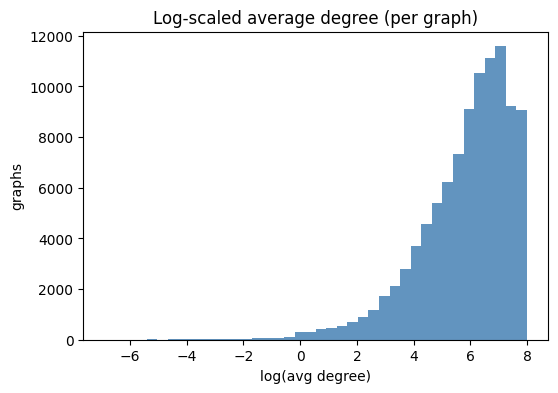

In [33]:


log_scaled = np.log2(avg_deg)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(log_scaled[np.isfinite(log_scaled)], bins=40, color='steelblue', alpha=0.85)
ax.set_title('Log-scaled average degree (per graph)')
ax.set_xlabel('log(avg degree)'); ax.set_ylabel('graphs')
plt.show()